## Data download

In [ ]:
# =============================================================================
# CELL 1 — DOWNLOAD DATASET FROM OPEN IMAGES V7
# =============================================================================
# Downloads segmentation masks for Car, Cat, and Bird from the Open Images v7
# dataset using FiftyOne Zoo. Each class is downloaded separately and merged
# into a single persistent dataset per split (train / validation / test).
#
# Only needs to run ONCE. After this, data is saved to disk and Cell 2 loads it.
# =============================================================================

import fiftyone as fo
import fiftyone.zoo as foz
import os

# --- Download Settings ---
# How many samples to download per class, per split
splits = {"train": 2000, "validation": 300, "test": 200}
classes = ["Car", "Cat", "Bird"]

for split, n_samples in splits.items():
    target_name = f"oi_{split}"  # e.g. "oi_train", "oi_validation", "oi_test"

    # Remove any stale dataset with the same name to start fresh
    if fo.dataset_exists(target_name):
        fo.delete_dataset(target_name)

    # Create an empty persistent FiftyOne dataset for this split
    dataset = fo.Dataset(target_name, persistent=True)

    # Download each class independently and merge into the split dataset
    for cls in classes:
        print(f"Downloading {cls} for {split}...")

        # Load only samples that have segmentation masks for this specific class
        ds = foz.load_zoo_dataset(
            "open-images-v7",
            split=split,
            label_types=["segmentations"],
            classes=[cls],
            max_samples=n_samples,
            only_matching=True,  # skip images that don't contain this class
        )

        # Merge this class's samples into the shared split dataset
        dataset.merge_samples(ds)

        # Delete the temporary per-class object to free memory
        ds.delete()

    print(f"{target_name}: {len(dataset)} total samples")

 100% |██████|    4.8Gb/4.8Gb [28.3s elapsed, 0s remaining, 279.9Mb/s]      
 100% |███████████████████| 800/800 [31.2s elapsed, 0s remaining, 31.4 files/s]      
Dataset info written to 'D:/open_images\open-images-v7\info.json'
Loading 'open-images-v7' split 'train'
 100% |█████████████████| 800/800 [46.7s elapsed, 0s remaining, 20.2 samples/s]      
Dataset 'open-images-v7-train-800' created
Converting existing index 'filepath' to unique on dataset 'open-images-v7-train-800'
Converting existing index 'filepath' to unique on dataset 'oi_train'
Found 1 images, downloading the remaining 799
 100% |███████████████████| 799/799 [35.9s elapsed, 0s remaining, 33.8 files/s]      
Dataset info written to 'D:/open_images\open-images-v7\info.json'
Loading 'open-images-v7' split 'train'
 100% |█████████████████| 800/800 [30.5s elapsed, 0s remaining, 25.7 samples/s]      
Dataset 'open-images-v7-train-800' created
Converting existing index 'filepath' to unique on dataset 'open-images-v7-train-800

In [ ]:
# =============================================================================
# CELL 1B — DOWNLOAD NOISE/BACKGROUND IMAGES (ALL-BLACK MASKS)
# =============================================================================
# Downloads images that contain NONE of Car, Cat, or Bird.
# These act as "hard negatives" — the model must learn to predict background
# for the entire image. Their masks are all zeros by construction.
#
# Strategy: download images from visually distinct but plausible classes
# (e.g. furniture, food, landscapes) that will never contain our targets.
# =============================================================================

import fiftyone as fo
import fiftyone.zoo as foz
import numpy as np
import os

# Classes that are not Car / Cat / Bird.

NOISE_CLASSES = [
    "Airplane", "Table", "Flower", "Teapot", "Laptop",
    "Person", "Book", "Bottle", "Apple", "Clothing"
]

TARGET_CLASSES = {"Car", "Cat", "Bird"}  # must NOT appear in noise images

# How many noise samples to add per split
NOISE_COUNTS = {"train": 400, "validation": 50, "test": 50}

for split, n_noise in NOISE_COUNTS.items():
    noise_name = f"oi_noise_{split}"

    if fo.dataset_exists(noise_name):
        fo.delete_dataset(noise_name)

    noise_dataset = fo.Dataset(noise_name, persistent=True)

    per_class = max(1, n_noise // len(NOISE_CLASSES))

    for cls in NOISE_CLASSES:
        print(f"Downloading noise class '{cls}' for {split} ({per_class} samples)...")
        try:
            ds = foz.load_zoo_dataset(
                "open-images-v7",
                split=split,
                label_types=["segmentations"],
                classes=[cls],
                max_samples=per_class,
                only_matching=True,
            )

            # ---------------------------------------------------------------
            # FILTER: discard any image that accidentally contains a target
            # class. Open Images images can have multiple annotations, so a
            # "Chair" image might also show a Cat in the background.
            # ---------------------------------------------------------------
            clean_ids = []
            for sample in ds:
                labels = sample.get("segmentations", None) or sample.get("ground_truth", None)
                if labels is None or not hasattr(labels, "detections"):
                    clean_ids.append(sample.id)
                    continue

                has_target = any(
                    det.label in TARGET_CLASSES
                    for det in labels.detections
                    if det.label is not None
                )
                if not has_target:
                    clean_ids.append(sample.id)

            clean_view = ds.select(clean_ids)
            noise_dataset.merge_samples(clean_view)
            ds.delete()

        except Exception as e:
            print(f"  Skipping '{cls}' ({e})")
            continue

    print(f"{noise_name}: {len(noise_dataset)} clean noise samples")

# Colab setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# All checkpoints during training are saved here — survives runtime disconnects
CHECKPOINT_DIR = "/content/drive/MyDrive/segmentation_checkpoints"
import os
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

Mounted at /content/drive


In [2]:
import os

zip_path = "/content/drive/MyDrive/open_images.zip"
print("Zip exists:", os.path.exists(zip_path))
print("Zip size:  ", os.path.getsize(zip_path) / 1024**3, "GB")

Zip exists: True
Zip size:   3.900879180058837 GB


In [6]:
import shutil
print("Copying zip to local runtime...")
shutil.copy(zip_path, "/content/open_images.zip")
print("Done copying")

Copying zip to local runtime...
Done copying


In [8]:
import zipfile
print("Unzipping...")
with zipfile.ZipFile("/content/open_images.zip", "r") as z:
    z.extractall("/content/open_images")
print("Done unzipping")

Unzipping...
Done unzipping


In [9]:
for root, dirs, files in os.walk("/content/open_images"):
    if files:
        print(f"{root}: {len(files)} files")

/content/open_images/open_images/open-images-v7: 1 files
/content/open_images/open_images/open-images-v7/validation/data: 834 files
/content/open_images/open_images/open-images-v7/validation/labels: 1 files
/content/open_images/open_images/open-images-v7/validation/labels/masks/C: 1665 files
/content/open_images/open_images/open-images-v7/validation/labels/masks/0: 1566 files
/content/open_images/open_images/open-images-v7/validation/labels/masks/D: 1504 files
/content/open_images/open_images/open-images-v7/validation/labels/masks/3: 1765 files
/content/open_images/open_images/open-images-v7/validation/labels/masks/6: 1495 files
/content/open_images/open_images/open-images-v7/validation/labels/masks/F: 1391 files
/content/open_images/open_images/open-images-v7/validation/labels/masks/2: 1447 files
/content/open_images/open_images/open-images-v7/validation/labels/masks/8: 1609 files
/content/open_images/open_images/open-images-v7/validation/labels/masks/4: 1473 files
/content/open_image

In [10]:
!pip install fiftyone -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.9/112.9 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 126.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 11.4 MB/s eta 

In [11]:
import fiftyone as fo

DATA_ROOT = "/content/open_images/open_images/open-images-v7"

def load_split(split, name):
    if fo.dataset_exists(name):
        fo.delete_dataset(name)
    return fo.Dataset.from_dir(
        dataset_type=fo.types.OpenImagesV7Dataset,
        dataset_dir=f"{DATA_ROOT}/{split}",   # point directly at train/, validation/, test/
        label_types=["segmentations"],
        name=name,
    )

train = load_split("train",      "oi_train")
val   = load_split("validation", "oi_validation")
test  = load_split("test",       "oi_test")

print(f"Train:      {len(train)} samples")
print(f"Validation: {len(val)} samples")
print(f"Test:       {len(test)} samples")


/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


 100% |███████████████| 6351/6351 [6.6m elapsed, 0s remaining, 23.4 samples/s]      


INFO:eta.core.utils: 100% |███████████████| 6351/6351 [6.6m elapsed, 0s remaining, 23.4 samples/s]      


 100% |█████████████████| 834/834 [34.9s elapsed, 0s remaining, 30.1 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 834/834 [34.9s elapsed, 0s remaining, 30.1 samples/s]      


 100% |█████████████████| 645/645 [26.9s elapsed, 0s remaining, 17.8 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 645/645 [26.9s elapsed, 0s remaining, 17.8 samples/s]      


Train:      6351 samples
Validation: 834 samples
Test:       645 samples


# Local setup

In [ ]:
# =============================================================================
# CELL 2 — LOAD EXISTING DATASETS FROM DISK
# =============================================================================
# Run this cell (instead of Cell 1) when the data is already downloaded.
# It reloads the three persistent FiftyOne datasets into memory.
# =============================================================================

import fiftyone as fo

# Verify that all three required datasets exist before trying to load them
required = ["oi_train", "oi_validation", "oi_test"]
missing = [name for name in required if not fo.dataset_exists(name)]

if missing:
    raise ValueError(
        "Missing datasets: " + ", ".join(missing) + ". Run Cell 1 first."
    )

# Load each split into a FiftyOne Dataset object
train = fo.load_dataset("oi_train")
val   = fo.load_dataset("oi_validation")
test  = fo.load_dataset("oi_test")

print(f"Train:      {len(train)} samples")
print(f"Validation: {len(val)} samples")
print(f"Test:       {len(test)} samples")

Train:      5999 samples
Validation: 790 samples
Test:       600 samples


# Visuals

Label field: ground_truth


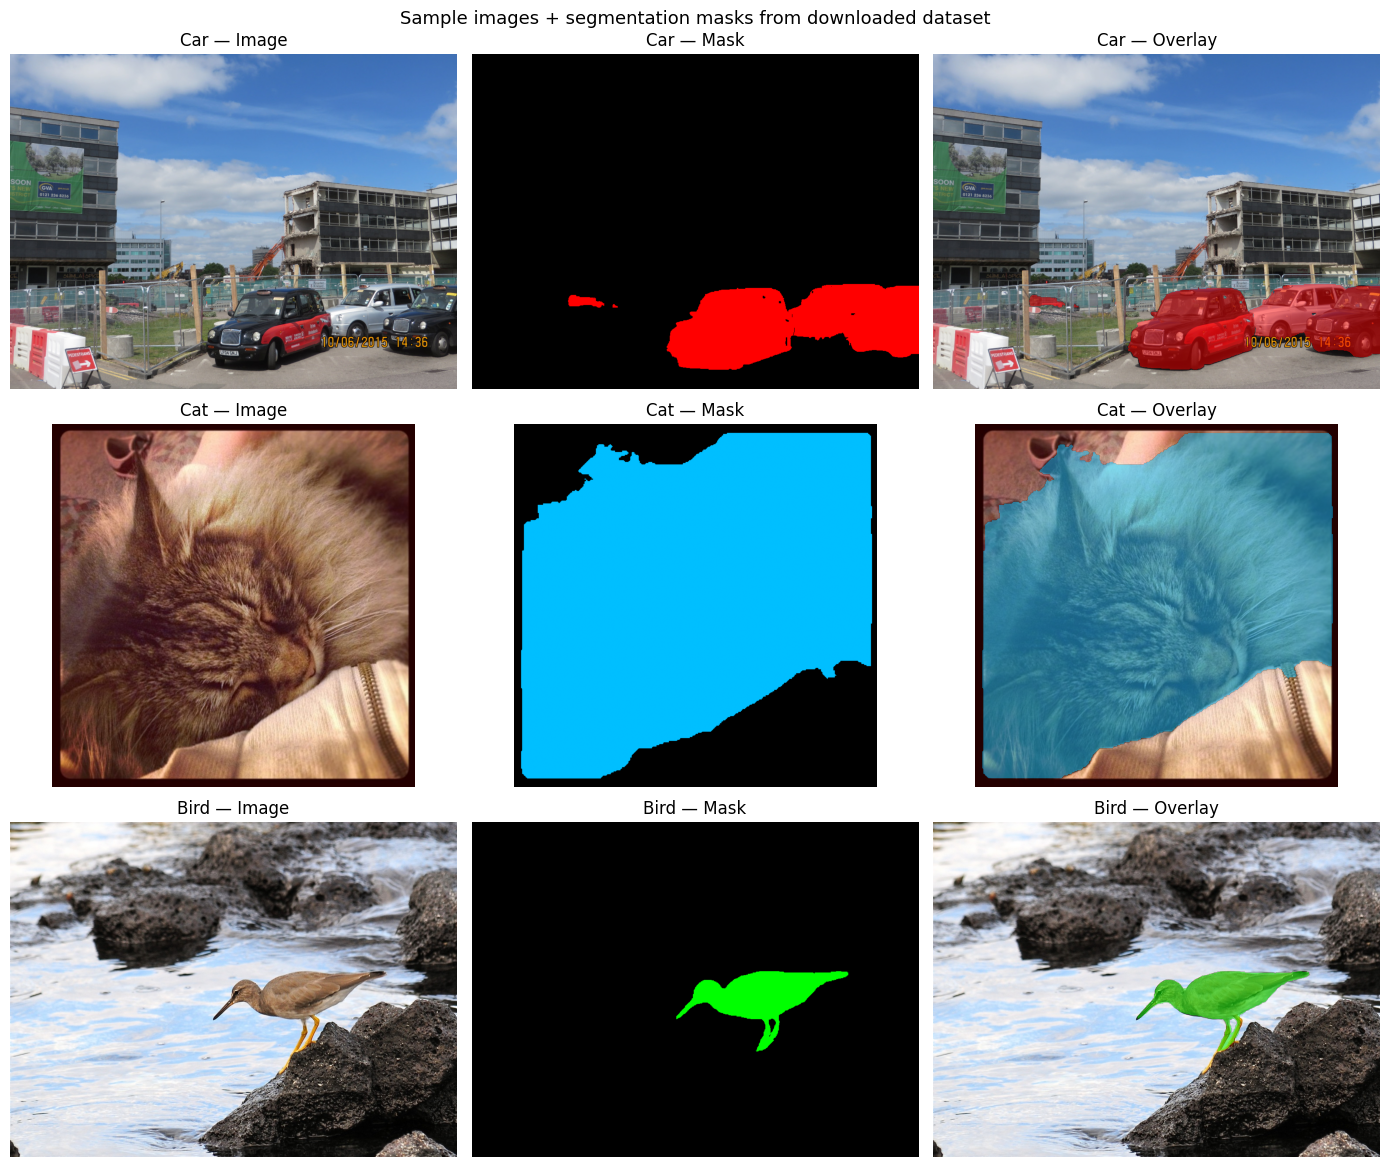

In [ ]:
# =============================================================================
# CELL 3 — VISUALIZE RAW DATA: ONE SAMPLE PER CLASS
# =============================================================================
# Quick sanity check: for each target class, find one training image and display:
#   col 1 — original image
#   col 2 — pixel-level segmentation mask (class colours)
#   col 3 — mask overlaid on the image (semi-transparent)
#
# Colour coding:  black=background  red=Car  deepskyblue=Cat  lime=Bird
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from fiftyone import ViewField as F
from matplotlib.colors import ListedColormap

target_classes = ["Car", "Cat", "Bird"]
class_to_id = {"Car": 1, "Cat": 2, "Bird": 3}  # 0 is reserved for background


def get_label_field(dataset):
    """Find the field name that stores segmentation labels in a FiftyOne dataset."""
    schema = dataset.get_field_schema()
    for name in ["segmentations", "ground_truth", "detections"]:
        if name in schema:
            return name
    raise ValueError("No label field found. Available: " + ", ".join(schema.keys()))


def build_mask(sample, field_name, class_to_id):
    """
    Reconstruct a full-resolution pixel-level label map from a FiftyOne sample.

    FiftyOne stores masks as small boolean patches inside each detection's
    bounding box (relative coordinates). This function:
      1. Opens the original image to get its dimensions
      2. Creates a blank (background=0) label map of the same size
      3. For each detection, resizes its patch to match the bounding box
         and stamps the class ID onto the label map
    """
    img = np.array(Image.open(sample.filepath).convert("RGB"))
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    labels = sample[field_name]
    if labels is None or not hasattr(labels, "detections"):
        return img, mask  # no annotations → return blank mask

    for det in labels.detections:
        if det.label not in class_to_id or det.mask is None:
            continue  # skip unlabelled or mask-less detections

        cid = class_to_id[det.label]

        # Bounding box is stored as relative [0,1] fractions → convert to pixels
        rx, ry, rw, rh = det.bounding_box
        x0, y0 = int(round(rx * w)), int(round(ry * h))
        bw, bh = max(1, int(round(rw * w))), max(1, int(round(rh * h)))

        if x0 >= w or y0 >= h:
            continue  # bounding box is outside the image

        # Resize the binary patch to exactly match the bounding box pixel dimensions
        patch = (np.array(det.mask) > 0).astype(np.uint8)
        patch = np.array(
            Image.fromarray(patch).resize((bw, bh), resample=Image.Resampling.NEAREST)
        )

        # Clip to image boundaries (box may slightly exceed image edge)
        x1, y1 = min(w, x0 + bw), min(h, y0 + bh)
        patch = patch[: y1 - y0, : x1 - x0]

        # Write class ID onto the label map; existing labels are NOT overwritten
        mask[y0:y1, x0:x1] = np.where(patch > 0, cid, mask[y0:y1, x0:x1])

    return img, mask


# --- Detect which field holds the labels ---
label_field = get_label_field(train)
print(f"Label field: {label_field}")

# Colour map: index 0=black(bg), 1=red(Car), 2=deepskyblue(Cat), 3=lime(Bird)
cmap = ListedColormap(["black", "red", "deepskyblue", "lime"])

fig, axes = plt.subplots(len(target_classes), 3, figsize=(14, 4 * len(target_classes)))

for r, cls in enumerate(target_classes):
    # Filter the training set to only images that contain this class
    view  = train.filter_labels(label_field, F("label") == cls)
    sample = view.first()
    img, mask = build_mask(sample, label_field, class_to_id)

    # Column 0: raw image
    axes[r, 0].imshow(img)
    axes[r, 0].set_title(f"{cls} — Image")
    axes[r, 0].axis("off")

    # Column 1: mask only (background pixels appear black)
    axes[r, 1].imshow(mask, cmap=cmap, vmin=0, vmax=3)
    axes[r, 1].set_title(f"{cls} — Mask")
    axes[r, 1].axis("off")

    # Column 2: mask overlaid on the image (background masked out → transparent)
    axes[r, 2].imshow(img)
    axes[r, 2].imshow(np.ma.masked_where(mask == 0, mask), cmap=cmap, alpha=0.5, vmin=0, vmax=3)
    axes[r, 2].set_title(f"{cls} — Overlay")
    axes[r, 2].axis("off")

plt.suptitle("Sample images + segmentation masks from downloaded dataset", fontsize=13)
plt.tight_layout()
plt.show()


# Model

In [12]:
# =============================================================================
# CELL 4 — PIPELINE SETUP: CONSTANTS, DEVICE, AND HELPER FUNCTIONS
# =============================================================================
# Defines all global hyperparameters and shared utility functions used across
# the rest of the notebook. Run this cell before any training or evaluation.
# =============================================================================

import random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# --- Reproducibility ---
# Fix all random seeds so results are reproducible across runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Use GPU if available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Class Configuration ---
CLASS_NAMES = ["Car", "Cat", "Bird"]
CLASS_TO_ID = {"Car": 1, "Cat": 2, "Bird": 3}  # class 0 = background
NUM_CLASSES = 1 + len(CLASS_NAMES)              # 4 total (bg + 3 foreground)

# --- Training Hyperparameters ---
IMG_SIZE   = 256   # all images are resized to 256×256 for the model
BATCH_SIZE = 8     # samples per gradient update
NUM_WORKERS = 0    # set >0 only if multiprocessing is supported on your system
MAX_EPOCHS = 60    # maximum training epochs (early stopping may end it earlier)
PATIENCE   = 10     # stop training after this many epochs with no val F1 improvement

# ---------------------------------------------------------------------------
# HELPER: detect the label field name for a FiftyOne dataset
# ---------------------------------------------------------------------------
def detect_label_field(dataset):
    """
    Returns the name of the field that stores segmentation/detection labels.
    Checks common field names first, then falls back to duck-typing the schema.
    """
    schema = dataset.get_field_schema()
    preferred = ["segmentations", "ground_truth", "detections"]
    for name in preferred:
        if name in schema:
            return name
    # Fallback: look for any field whose document type sounds like a detection
    for name, field_type in schema.items():
        if hasattr(field_type, "document_type") and field_type.document_type is not None:
            doc_name = field_type.document_type.__name__.lower()
            if "detection" in doc_name or "polyline" in doc_name or "segmentation" in doc_name:
                return name
    raise ValueError("No compatible label field found")


# ---------------------------------------------------------------------------
# HELPER: convert a FiftyOne sample's detections into a pixel-level label map
# ---------------------------------------------------------------------------
def build_label_map_from_sample(sample, field_name, class_to_id):
    """
    Creates a 2-D integer array (H × W) where each pixel holds a class ID.

    FiftyOne stores masks as small boolean patches within relative bounding boxes.
    This function:
      1. Opens the raw image to get its (H, W)
      2. Allocates a zero-filled label map (0 = background everywhere)
      3. For every detection that belongs to a target class:
         a. Converts the relative bounding box to absolute pixel coordinates
         b. Resizes the boolean mask patch to match the bounding box size
         c. Stamps the class ID onto the label map (existing IDs are NOT overwritten)

    Returns:
        img      (np.ndarray, H×W×3 uint8): the raw RGB image
        label_map (np.ndarray, H×W uint8):  pixel-level class IDs
    """
    img = np.array(Image.open(sample.filepath).convert("RGB"))
    h, w = img.shape[:2]
    label_map = np.zeros((h, w), dtype=np.uint8)

    labels = sample[field_name]
    if labels is None or not hasattr(labels, "detections"):
        return img, label_map  # sample has no annotations

    for det in labels.detections:
        if det.label not in class_to_id or det.mask is None:
            continue  # skip unlabelled detections and those without a mask patch

        class_id = class_to_id[det.label]

        # Convert relative bounding box [0,1] → absolute pixel coordinates
        rel_x, rel_y, rel_w, rel_h = det.bounding_box
        x0 = int(round(rel_x * w))
        y0 = int(round(rel_y * h))
        bw = max(1, int(round(rel_w * w)))
        bh = max(1, int(round(rel_h * h)))

        if x0 >= w or y0 >= h:
            continue  # bounding box starts outside the image

        # Binarise and resize the mask patch to the exact bounding box pixel size
        patch = (np.array(det.mask) > 0).astype(np.uint8)
        if patch.size == 0:
            continue
        patch = np.array(
            Image.fromarray(patch).resize((bw, bh), resample=Image.Resampling.NEAREST)
        )

        # Clamp to image boundaries in case the box slightly overflows
        x1 = min(w, x0 + bw)
        y1 = min(h, y0 + bh)
        if x1 <= x0 or y1 <= y0:
            continue

        patch = patch[: y1 - y0, : x1 - x0]
        # Only write class_id where the patch is active; don't overwrite existing labels
        label_map[y0:y1, x0:x1] = np.where(patch > 0, class_id, label_map[y0:y1, x0:x1])

    return img, label_map


# ---------------------------------------------------------------------------
# HELPER: filter a dataset — returns BOTH kept and rejected samples
# ---------------------------------------------------------------------------
def collect_samples_with_target_classes(dataset, field_name, class_names):
    """
    Returns:
        kept  — samples that have at least one target-class annotation
        noise — samples that have NO target-class annotations
    """
    kept, noise = [], []
    class_set = set(class_names)
    for sample in dataset:
        labels = sample[field_name]
        if labels is None or not hasattr(labels, "detections"):
            noise.append(sample)
            continue
        has_target = any(det.label in class_set for det in labels.detections)
        if has_target:
            kept.append(sample)
        else:
            noise.append(sample)
    return kept, noise


# ---------------------------------------------------------------------------
# HELPER: print how many samples contain each class in a given split
# ---------------------------------------------------------------------------
def verify_class_distribution(samples, field_name, class_to_id, split_name=""):
    """Prints a per-class count and percentage for the given sample list."""
    class_counts = {cls: 0 for cls in class_to_id}
    samples_per_class = {cls: [] for cls in class_to_id}

    for sample in samples:
        _, mask = build_label_map_from_sample(sample, field_name, class_to_id)
        for cls, cls_id in class_to_id.items():
            if np.any(mask == cls_id):
                class_counts[cls] += 1
                samples_per_class[cls].append(sample)

    print(f"\n{split_name} Class Distribution:")
    for cls, count in class_counts.items():
        pct = 100 * count / len(samples) if samples else 0
        print(f"  {cls}: {count} samples ({pct:.1f}%)")

    return class_counts, samples_per_class


# --- Build filtered sample lists for each split ---
label_field = detect_label_field(train)

train_samples, noise_train = collect_samples_with_target_classes(train, label_field, CLASS_NAMES)
val_samples,   noise_val   = collect_samples_with_target_classes(val,   label_field, CLASS_NAMES)
test_samples,  noise_test  = collect_samples_with_target_classes(test,  label_field, CLASS_NAMES)

# Shuffle val/test with a fixed seed for reproducibility
random.seed(SEED)
random.shuffle(val_samples)
random.shuffle(test_samples)

print(f"Label field: {label_field}")
print(f"Filtered  → train: {len(train_samples)}, val: {len(val_samples)}, test: {len(test_samples)}")
print(f"Noise     → train: {len(noise_train)}, val: {len(noise_val)}, test: {len(noise_test)}")

Using device: cuda
Label field: ground_truth
Filtered  → train: 5999, val: 790, test: 600
Noise     → train: 352, val: 44, test: 45


In [ ]:
# =============================================================================
# Check pixel-level class distribution across the filtered samples. This is a sanity
# check to ensure that the dataset contains a reasonable number of pixels for each class.
# =============================================================================

import numpy as np
from collections import defaultdict

def check_pixel_distribution(samples, label_field, class_to_id, split_name=""):
    """
    Counts total pixels per class across all samples.
    Prints counts, percentages, and a rough ASCII bar chart.
    """
    id_to_name = {0: "background"} | {v: k for k, v in class_to_id.items()}
    num_classes = len(class_to_id) + 1  # +1 for background

    total_pixels = defaultdict(int)
    total        = 0

    for sample in samples:
        _, mask = build_label_map_from_sample(sample, label_field, class_to_id)
        for cls_id in range(num_classes):
            count = int(np.sum(mask == cls_id))
            total_pixels[cls_id] += count
            total += count if cls_id == 0 else 0  # count total once

    total = sum(total_pixels.values())

    print(f"\n{'='*55}")
    print(f"Pixel distribution — {split_name} ({len(samples)} samples)")
    print(f"{'='*55}")
    print(f"{'Class':<15} {'Pixels':>12} {'%':>8}  Bar")
    print(f"{'-'*55}")

    for cls_id in range(num_classes):
        name  = id_to_name.get(cls_id, f"class_{cls_id}")
        count = total_pixels[cls_id]
        pct   = 100 * count / total if total > 0 else 0
        bar   = "█" * int(pct / 2)  # scale: 1 block = 2%
        print(f"{name:<15} {count:>12,} {pct:>7.2f}%  {bar}")

    print(f"{'─'*55}")
    print(f"{'TOTAL':<15} {total:>12,} {'100.00%':>8}")


# Run on all splits
check_pixel_distribution(train_samples, label_field, CLASS_TO_ID, "train")
check_pixel_distribution(val_samples,   label_field, CLASS_TO_ID, "validation")
check_pixel_distribution(test_samples,  label_field, CLASS_TO_ID, "test")


Pixel distribution — train (5999 samples)
Class                 Pixels        %  Bar
-------------------------------------------------------
background      3,595,110,685   78.87%  ███████████████████████████████████████
Car              337,170,248    7.40%  ███
Cat              469,582,687   10.30%  █████
Bird             156,146,044    3.43%  █
───────────────────────────────────────────────────────
TOTAL           4,558,009,664  100.00%

Pixel distribution — validation (790 samples)
Class                 Pixels        %  Bar
-------------------------------------------------------
background       485,542,944   72.66%  ████████████████████████████████████
Car               46,276,211    6.93%  ███
Cat              110,445,802   16.53%  ████████
Bird              25,961,824    3.89%  █
───────────────────────────────────────────────────────
TOTAL            668,226,781  100.00%

Pixel distribution — test (600 samples)
Class                 Pixels        %  Bar
----------------------

In [ ]:
# =============================================================================
# CELL 5 — MERGE NOISE SAMPLES INTO TRAINING DATA
# =============================================================================
# noise_train/val/test were captured in Cell 4 as the rejected samples.
# build_label_map_from_sample returns all-zero masks for them automatically.
# =============================================================================

train_samples = train_samples + noise_train
val_samples   = val_samples   + noise_val
test_samples  = test_samples  + noise_test

print(f"After noise injection → train: {len(train_samples)}, "
      f"val: {len(val_samples)}, test: {len(test_samples)}")

After noise injection → train: 6351, val: 834, test: 645


In [ ]:
# =============================================================================
# CELL 5 — PRODUCTION DATASET, DATALOADERS, AND WEIGHTED SAMPLER
# =============================================================================
# FiftyOneSegDataset is the dataset class actually used during training.
#
# To handle the class imbalance (Car >> Cat ≈ Bird in Open Images), the
# training DataLoader uses a WeightedRandomSampler that over-samples images
# containing Cat or Bird, giving the model more exposure to minority classes.
# =============================================================================

from matplotlib import image
from torch.utils.data import Dataset


class FiftyOneSegDataset(Dataset):
    """
    PyTorch Dataset wrapping FiftyOne segmentation samples.

    Preprocessing (must match at inference time):
      - Resize image to (image_size × image_size) with bilinear interpolation
      - Resize mask  to (image_size × image_size) with nearest-neighbour
      - Normalise image pixels to [0, 1] by dividing by 255
      - Return image as float32 tensor [C, H, W] and mask as int64 tensor [H, W]
    """

    def __init__(self, samples, field_name, class_to_id, image_size=256):
        self.samples    = samples
        self.field_name = field_name
        self.class_to_id = class_to_id
        self.image_size  = image_size

    def __len__(self):
        return len(self.samples)



    def __getitem__(self, idx):
        sample = self.samples[idx]
        image, label_map = build_label_map_from_sample(sample, self.field_name, self.class_to_id)

        image     = Image.fromarray(image).resize(
            (self.image_size, self.image_size), resample=Image.Resampling.BILINEAR
        )
        label_map = Image.fromarray(label_map).resize(
            (self.image_size, self.image_size), resample=Image.Resampling.NEAREST
        )

        image     = np.array(image).astype(np.float32) / 255.0   # simple normalisation
        label_map = np.array(label_map).astype(np.int64)

        image     = torch.from_numpy(image).permute(2, 0, 1)
        label_map = torch.from_numpy(label_map)
        return image, label_map


def create_weighted_sampler(samples, field_name, class_to_id):
    """
    Sampler weights derived from actual pixel distribution:
      background: 78.87%  → suppress heavily
      Car:         7.40%  → baseline
      Cat:        10.30%  → Cat is MORE common than Car pixel-wise
      Bird:        3.43%  → rarest foreground, boost most

    """
    weights = []

    for sample in samples:
        _, mask = build_label_map_from_sample(sample, field_name, class_to_id)

        has_car  = np.any(mask == class_to_id["Car"])
        has_cat  = np.any(mask == class_to_id["Cat"])
        has_bird = np.any(mask == class_to_id["Bird"])

        has_any_foreground = has_car or has_cat or has_bird

        if not has_any_foreground:
            weight = 0.2          

        elif has_bird and has_cat:
            weight = 8.0          

        elif has_bird:
            weight = 4.0          

        elif has_cat and not has_car:
            weight = 1.5          

        elif has_car and not has_cat:
            weight = 2.0         

        else:
            weight = 1.5          

        weights.append(weight)

    return WeightedRandomSampler(weights, len(weights), replacement=True)

# --- Build dataset objects for all three splits ---
train_dataset = FiftyOneSegDataset(train_samples, label_field, CLASS_TO_ID, image_size=IMG_SIZE)
val_dataset   = FiftyOneSegDataset(val_samples,   label_field, CLASS_TO_ID, image_size=IMG_SIZE)
test_dataset  = FiftyOneSegDataset(test_samples,  label_field, CLASS_TO_ID, image_size=IMG_SIZE)

if len(train_dataset) == 0 or len(val_dataset) == 0:
    raise ValueError("Train/val split has no usable samples. Check labels and class filters.")

# Training loader uses weighted sampling (no shuffle — sampler handles ordering)
train_sampler = create_weighted_sampler(train_samples, label_field, CLASS_TO_ID)
train_loader  = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=NUM_WORKERS
)

# Validation and test loaders iterate in a fixed order (no shuffle needed)
val_loader  = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")


Train batches: 750
Val batches:   99
Test batches:  75


Training augmentation enabled with WeightedRandomSampler.
Train batches: 794


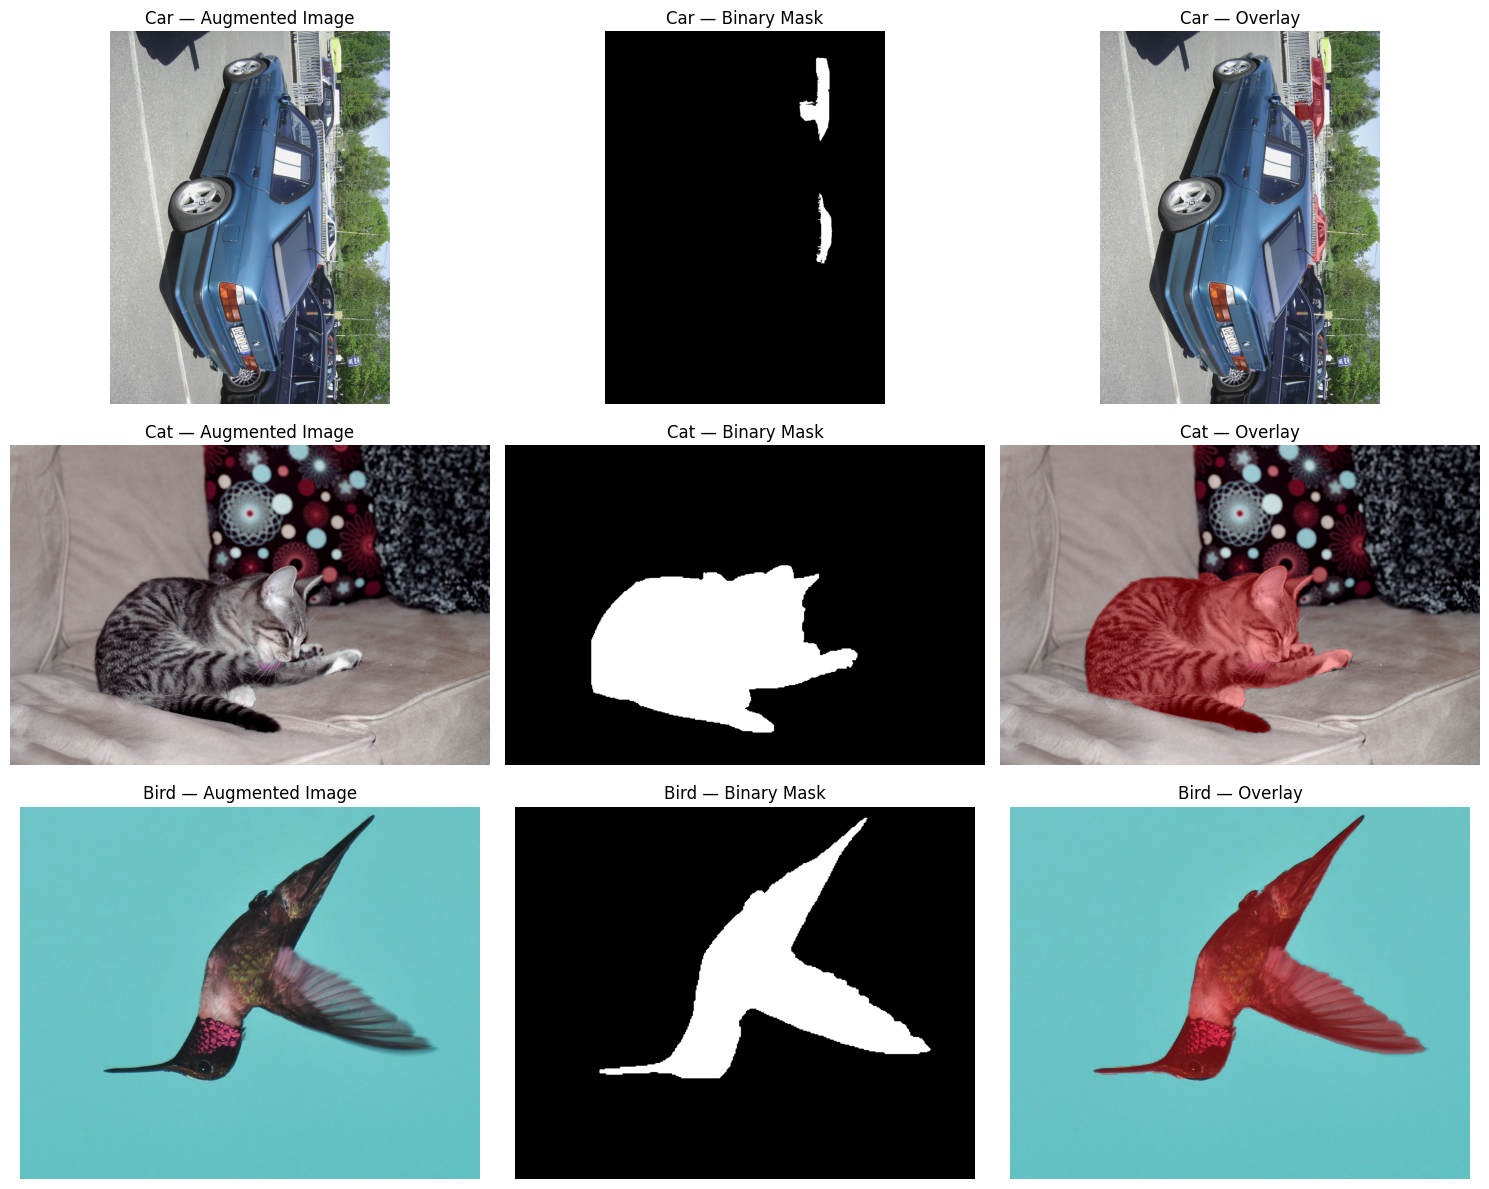

In [ ]:
# =============================================================================
# CELL 6 — DATA AUGMENTATION FOR TRAINING
# =============================================================================
# Wraps the training dataset with online augmentation applied at load time.
# The same geometric transform is applied to BOTH the image and the mask to
# keep them in sync. Colour/brightness jitter is only applied to the image.
#
# Augmentations applied:
#   - Random horizontal flip     (p=0.5)
#   - Random vertical flip       (p=0.3)
#   - Random 90° rotation        (k ∈ {0,1,2,3})
#   - Mild brightness/contrast jitter ±15%  (image only)
# =============================================================================

import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF


def augment_image_mask(image, mask):
    """
    Applies the same random geometric transforms to image and mask.
    Photometric changes (brightness/contrast) are applied to the image only,
    since class IDs in the mask must remain integers — never interpolated.

    Args:
        image (torch.Tensor): float32 [C, H, W] in range [0, 1]
        mask  (torch.Tensor): int64  [H, W] with class IDs

    Returns:
        (image, mask) after augmentation
    """
    # --- Geometric transforms (applied identically to image and mask) ---
    if random.random() < 0.5:
        image = TF.hflip(image)
        mask  = TF.hflip(mask.unsqueeze(0)).squeeze(0)  # hflip needs [C,H,W]

    if random.random() < 0.3:
        image = TF.vflip(image)
        mask  = TF.vflip(mask.unsqueeze(0)).squeeze(0)

    # Rotate by 0°, 90°, 180°, or 270° — only exact multiples avoid interpolation
    k = random.randint(0, 3)
    if k:
        image = torch.rot90(image, k, dims=(1, 2))
        mask  = torch.rot90(mask,  k, dims=(0, 1))



    # --- Photometric transforms (applied to image only) ---
    image = TF.adjust_saturation(image, 1.0 + random.uniform(-0.3, 0.3))
    image = TF.adjust_hue(image, random.uniform(-0.1, 0.1))

    # --- Photometric augmentation (image only) ---
    image = TF.adjust_brightness(image, 1.0 + random.uniform(-0.15, 0.15))
    image = TF.adjust_contrast(image,   1.0 + random.uniform(-0.15, 0.15))
    image = torch.clamp(image, 0.0, 1.0)  # keep values in valid range

    return image, mask


class AugmentedTrainDataset(Dataset):
    """
    Dataset wrapper that applies an augmentation function at every __getitem__
    call, so each epoch sees a different random transformation of each sample.
    """

    def __init__(self, base_dataset, augment_fn):
        self.base_dataset = base_dataset
        self.augment_fn   = augment_fn

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, mask = self.base_dataset[idx]
        image, mask = self.augment_fn(image, mask)
        return image, mask


def apply_train_augmentation_if_ready():
    global train_dataset, train_loader

    if "train_dataset" not in globals():
        print("train_dataset is not defined yet. Run Cell 5 first.")
        return False

    # Prevent stacking wrappers on repeated runs
    if isinstance(train_dataset, AugmentedTrainDataset):
        base_dataset = train_dataset.base_dataset
    else:
        base_dataset = train_dataset

    train_dataset = AugmentedTrainDataset(base_dataset, augment_image_mask)

    batch_size  = BATCH_SIZE  if "BATCH_SIZE"  in globals() else 8
    num_workers = NUM_WORKERS if "NUM_WORKERS" in globals() else 0

    # Rebuild the sampler from the ORIGINAL sample list (not the wrapper)
    sampler = create_weighted_sampler(train_samples, label_field, CLASS_TO_ID)


    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        sampler=sampler,          
        num_workers=num_workers,
    )

    print(f"Training augmentation enabled with WeightedRandomSampler.")
    print(f"Train batches: {len(train_loader)}")
    return True


def plot_augmented_per_class(max_tries=400):
    """
    Visualises one augmented example per class (image, binary class mask, overlay).
    Scans up to max_tries training samples to find at least one per class.
    """
    needed = list(CLASS_NAMES) if "CLASS_NAMES" in globals() else ["Car", "Cat", "Bird"]

    if "train_samples" not in globals() or "label_field" not in globals() or "CLASS_TO_ID" not in globals():
        print("Missing train_samples / label_field / CLASS_TO_ID. Run Cell 4 first.")
        return

    class_to_id = CLASS_TO_ID
    found = {c: None for c in needed}  # store one (image, mask) pair per class

    # Shuffle indices so we get a random sample on each call
    indices = list(range(len(train_samples)))
    random.shuffle(indices)

    for idx in indices[: min(max_tries, len(train_samples))]:
        sample   = train_samples[idx]
        image_np, mask_np = build_label_map_from_sample(sample, label_field, class_to_id)

        for cls in needed:
            if found[cls] is None and np.any(mask_np == class_to_id[cls]):
                found[cls] = (image_np, mask_np)

        if all(found[c] is not None for c in needed):
            break  # found one example for every class

    fig, axes = plt.subplots(len(needed), 3, figsize=(15, 4 * len(needed)))
    if len(needed) == 1:
        axes = np.expand_dims(axes, axis=0)

    for r, cls in enumerate(needed):
        if found[cls] is None:
            axes[r, 0].set_title(f"{cls} (not found in {max_tries} tries)")
            for ax in axes[r]:
                ax.axis("off")
            continue

        image_np, mask_np = found[cls]

        # Convert to tensors and apply augmentation
        image_t = torch.from_numpy(image_np.astype(np.float32) / 255.0).permute(2, 0, 1)
        mask_t  = torch.from_numpy(mask_np.astype(np.int64))
        aug_img_t, aug_mask_t = augment_image_mask(image_t, mask_t)

        # Convert back to numpy for plotting
        aug_img  = (aug_img_t.permute(1, 2, 0).cpu().numpy() * 255.0).astype(np.uint8)
        cls_id   = class_to_id[cls]
        cls_mask = (aug_mask_t.cpu().numpy() == cls_id).astype(np.uint8)

        axes[r, 0].imshow(aug_img)
        axes[r, 0].set_title(f"{cls} — Augmented Image")
        axes[r, 0].axis("off")

        axes[r, 1].imshow(cls_mask, cmap="gray")
        axes[r, 1].set_title(f"{cls} — Binary Mask")
        axes[r, 1].axis("off")

        axes[r, 2].imshow(aug_img)
        axes[r, 2].imshow(
            np.ma.masked_where(cls_mask == 0, cls_mask), alpha=0.35, cmap="autumn"
        )
        axes[r, 2].set_title(f"{cls} — Overlay")
        axes[r, 2].axis("off")

    plt.tight_layout()
    plt.show()


# Apply augmentation wrapper and visualise one example per class
_ = apply_train_augmentation_if_ready()
plot_augmented_per_class()


In [15]:
# =============================================================================
# CELL 7 — U-NET MODEL DEFINITION
# =============================================================================
# Implements the classic U-Net encoder–decoder architecture with skip connections.
#
# Architecture summary (default features=(32, 64, 128, 256)):
#
#   Encoder (downsampling path):
#     Input (3ch) → DoubleConv → 32ch → MaxPool
#                             → 64ch → MaxPool
#                             → 128ch → MaxPool
#                             → 256ch → MaxPool
#
#   Bottleneck:
#                             → 512ch  (widest point; captures global context)
#
#   Decoder (upsampling path):
#     512ch → ConvTranspose2d → 256ch ─┐  (skip from encoder)
#                             → DoubleConv(256+256=512 → 256ch)
#             ConvTranspose2d → 128ch ─┐
#                             → DoubleConv(128+128 → 128ch)
#             ConvTranspose2d → 64ch  ─┐
#                             → DoubleConv(64+64 → 64ch)
#             ConvTranspose2d → 32ch  ─┐
#                             → DoubleConv(32+32 → 32ch)
#
#   Output:
#     1×1 Conv → n_classes logits per pixel
#
# Skip connections concatenate encoder feature maps into the decoder at each
# resolution level, helping the model recover fine spatial details.
# =============================================================================


class DoubleConv(nn.Module):
    """
    Two successive Conv2d → BatchNorm → ReLU blocks.
    This is the basic building block of both the encoder and decoder.
    Using BatchNorm stabilises training; bias=False because BN already adds bias.
    """

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """
    U-Net for multi-class semantic segmentation.

    Args:
        in_channels (int): number of input image channels (3 for RGB)
        n_classes   (int): number of output classes (including background)
        features   (tuple): channel widths at each encoder stage
    """

    def __init__(self, in_channels=3, n_classes=4, features=(32, 64, 128, 256)):
        super().__init__()
        self.downs     = nn.ModuleList()   # encoder DoubleConv blocks
        self.ups       = nn.ModuleList()   # decoder (ConvTranspose + DoubleConv) pairs
        self.pool      = nn.MaxPool2d(kernel_size=2, stride=2)  # halves spatial dims

        # --- Encoder: build one DoubleConv block per feature level ---
        ch = in_channels
        for feat in features:
            self.downs.append(DoubleConv(ch, feat))
            ch = feat

        # --- Bottleneck: widest feature map (no pooling) ---
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # --- Decoder: for each level, upsample then merge with skip connection ---
        rev   = list(reversed(features))
        up_ch = features[-1] * 2  # starts at bottleneck width (512)
        for feat in rev:
            # ConvTranspose2d doubles spatial resolution and halves channels
            self.ups.append(nn.ConvTranspose2d(up_ch, feat, kernel_size=2, stride=2))
            # After concatenating the skip connection, channels are doubled again
            self.ups.append(DoubleConv(feat * 2, feat))
            up_ch = feat

        # --- Output head: maps from smallest feature width to class logits ---
        self.out_conv = nn.Conv2d(features[0], n_classes, kernel_size=1)

    def forward(self, x):
        skips = []

        # --- Encoder pass: save feature maps before each pool for skip connections ---
        for down in self.downs:
            x = down(x)
            skips.append(x)   # save before pooling
            x = self.pool(x)  # halve spatial resolution

        # --- Bottleneck ---
        x = self.bottleneck(x)

        # Reverse skips so the deepest (smallest) is matched with the first decoder stage
        skips = skips[::-1]

        # --- Decoder pass: upsample, concatenate skip, apply DoubleConv ---
        for i in range(0, len(self.ups), 2):
            x    = self.ups[i](x)       # ConvTranspose2d: doubles H and W
            skip = skips[i // 2]

            # Handle any off-by-one size mismatch caused by odd input dimensions
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

            # Concatenate along the channel dimension to merge skip features
            x = torch.cat((skip, x), dim=1)
            x = self.ups[i + 1](x)     # DoubleConv: fuse concatenated channels

        # --- 1×1 conv to produce per-pixel class logits ---
        return self.out_conv(x)


# Instantiate the model and move to the target device
model = UNet(in_channels=3, n_classes=NUM_CLASSES).to(device)
print(model.__class__.__name__)

UNet


In [ ]:
from torchsummary import summary

summary(model, (3, 256, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 256, 256]             864
       BatchNorm2d-2         [-1, 32, 256, 256]              64
              ReLU-3         [-1, 32, 256, 256]               0
            Conv2d-4         [-1, 32, 256, 256]           9,216
       BatchNorm2d-5         [-1, 32, 256, 256]              64
              ReLU-6         [-1, 32, 256, 256]               0
        DoubleConv-7         [-1, 32, 256, 256]               0
         MaxPool2d-8         [-1, 32, 128, 128]               0
            Conv2d-9         [-1, 64, 128, 128]          18,432
      BatchNorm2d-10         [-1, 64, 128, 128]             128
             ReLU-11         [-1, 64, 128, 128]               0
           Conv2d-12         [-1, 64, 128, 128]          36,864
      BatchNorm2d-13         [-1, 64, 128, 128]             128
             ReLU-14         [-1, 64, 1

In [ ]:
# =============================================================================
# COUNT TRAINABLE PARAMETERS
# =============================================================================

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {frozen_params:,}")
print(f"Model size (approx):  {total_params * 4 / 1024**2:.2f} MB") 

Total parameters:     7,763,140
Trainable parameters: 7,763,140
Frozen parameters:    0
Model size (approx):  29.61 MB


In [ ]:
# =============================================================================
# CELL 8 — LOSS FUNCTIONS, METRICS, AND OPTIMISER SETUP
# =============================================================================
# The training objective is a weighted combination of Focal Loss and Dice Loss:
#
#   L_total = 0.5 × L_Focal  +  0.5 × L_Dice
#
# Focal Loss:  down-weights easy (well-classified) pixels so the model focuses
#              on hard, misclassified ones. Controlled by gamma (γ=2).
#              Class weights are applied to additionally penalise errors on
#              minority classes (Cat, Bird).
#
# Dice Loss:   directly maximises the overlap (IoU) between predicted and
#              ground-truth masks for each class. More stable than cross-entropy
#              when classes are highly imbalanced.
#
# Class weights are estimated from the actual training pixel distribution so
#              the loss automatically compensates for background dominance.
# =============================================================================


class DiceLoss(nn.Module):
    """
    Soft Dice Loss over all classes simultaneously.

    The Dice coefficient for class c is:
        Dice_c = (2 × |P_c ∩ T_c| + ε) / (|P_c| + |T_c| + ε)

    where P_c = predicted probabilities for class c (after softmax)
    and   T_c = one-hot ground-truth for class c.
    Loss = 1 − mean(Dice_c over all classes).
    """

    def __init__(self, n_classes, smooth=1e-6):
        super().__init__()
        self.n_classes = n_classes
        self.smooth    = smooth  # prevents division by zero

    def forward(self, logits, targets):
        # Convert logits to class probabilities
        probs   = torch.softmax(logits, dim=1)
        # Convert integer class map to one-hot: (B, H, W) → (B, C, H, W)
        one_hot = F.one_hot(targets, num_classes=self.n_classes).permute(0, 3, 1, 2).float()

        # Flatten spatial dimensions for dot-product computation
        probs   = probs.reshape(probs.shape[0],   probs.shape[1],   -1)
        one_hot = one_hot.reshape(one_hot.shape[0], one_hot.shape[1], -1)

        intersection = (probs * one_hot).sum(dim=2)
        union        = probs.sum(dim=2) + one_hot.sum(dim=2)
        dice         = (2.0 * intersection + self.smooth) / (union + self.smooth)

        return 1.0 - dice.mean()  # 0 = perfect; 1 = worst


class FocalLoss(nn.Module):
    """
    Focal Loss for dense prediction.

    Standard cross-entropy treats every pixel equally. Focal loss adds a
    modulating factor (1 − p_t)^γ that reduces the contribution of easy
    (correctly classified) pixels, forcing the model to focus on hard ones.

    L_focal = −(1 − p_t)^γ × log(p_t)

    Args:
        alpha  : per-class weight tensor (same as class_weight in nn.CrossEntropyLoss)
        gamma  : focusing parameter; higher γ → more focus on hard examples
        reduction: 'mean' or 'sum'
    """

    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha     = alpha
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # Compute per-pixel cross-entropy (with optional class weights)
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce)                      # p_t = probability of the correct class
        focal = (1 - pt) ** self.gamma * ce      # down-weight easy, up-weight hard pixels

        return focal.mean() if self.reduction == "mean" else focal.sum()


class CombinedLoss(nn.Module):
    """
    Weighted sum of Focal Loss and Dice Loss.

    Using both together:
      - Focal handles hard pixels and class imbalance at a per-pixel level
      - Dice directly optimises segmentation overlap at a mask level
    """

    def __init__(self, n_classes, focal_weight=0.3, dice_weight=0.7, ce_class_weights=None, gamma=2.0):
        super().__init__()
        self.focal = FocalLoss(alpha=ce_class_weights, gamma=gamma) 
        self.dice         = DiceLoss(n_classes=n_classes)
        self.focal_weight = focal_weight
        self.dice_weight  = dice_weight

    def forward(self, logits, targets):
        focal_loss = self.focal(logits, targets)
        dice_loss = self.dice(logits, targets)
        return self.focal_weight * focal_loss + self.dice_weight * dice_loss

def pixel_accuracy(logits, targets):
    """Fraction of pixels whose predicted class matches the ground truth."""
    preds   = torch.argmax(logits, dim=1)
    correct = (preds == targets).float().mean().item()
    return correct


# ---------------------------------------------------------------------------
# METRIC: mean IoU per class
# ---------------------------------------------------------------------------
def calculate_iou(logits, targets, n_classes):
    """Computes mean IoU over all classes that appear in the batch."""
    preds = torch.argmax(logits, dim=1)
    ious  = []
    for cls in range(n_classes):
        inter = ((preds == cls) & (targets == cls)).sum().float()
        union = ((preds == cls) | (targets == cls)).sum().float()
        if union > 0:
            ious.append(inter / union)
    return torch.tensor(ious).mean().item()


# ---------------------------------------------------------------------------
# CLASS WEIGHT ESTIMATION
# ---------------------------------------------------------------------------
def estimate_class_weights(loader, num_classes, device, max_batches=50):
    counts = torch.zeros(num_classes, dtype=torch.float64)
    seen = 0

    for _, masks in loader:
        hist = torch.bincount(masks.view(-1), minlength=num_classes).to(torch.float64)
        counts += hist
        seen += 1
        if max_batches is not None and seen >= max_batches:
            break

    print("Pixel counts:", counts)

    # Goal: foreground classes all weighted ~equally, background dampened
    weights = torch.ones(num_classes, dtype=torch.float32)


    weights[0] *= 0.05   # background suppress hard
                    
    weights[1] *= 2.5    # Car — moderate boost

    weights[2] *= 1.5    # Cat — mild boost 

    weights[3] *= 3.0    # Bird — strong boost

    weights = weights / weights.mean()  # normalise to keep average weight around 1.0

    print("Manual class weights:", weights)
    return weights.to(device)


# --- Compute class weights from training data ---
class_weights = estimate_class_weights(train_loader, NUM_CLASSES, device=device)
print("Class weights (bg, Car, Cat, Bird):", class_weights.detach().cpu().numpy())

# --- Instantiate loss, optimiser, and learning-rate scheduler ---
criterion = CombinedLoss(
    n_classes=NUM_CLASSES,
    focal_weight=0.5,       # 50% Focal Loss
    dice_weight=0.5,        # 50% Dice Loss
    ce_class_weights=class_weights,
    gamma=3.0,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4,
)


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=MAX_EPOCHS,  
    eta_min=1e-7,
)


Pixel counts: tensor([21700309.,  1426185.,  1803496.,  1284410.], dtype=torch.float64)
Manual class weights: tensor([0.0284, 1.4184, 0.8511, 1.7021])
Class weights (bg, Car, Cat, Bird): [0.02836879 1.4184396  0.8510638  1.7021276 ]


No checkpoint found — starting from scratch.
Epoch 01/60 | train_loss=0.4755  val_loss=0.4648 | train_acc=0.4674  val_acc=0.3847 | train_fg_f1=0.1564  val_fg_f1=0.1535
  ✅ New best val_fg_f1=0.1535 — saved best_model.pt
Epoch 02/60 | train_loss=0.4546  val_loss=0.4432 | train_acc=0.5262  val_acc=0.5073 | train_fg_f1=0.2006  val_fg_f1=0.2379
  ✅ New best val_fg_f1=0.2379 — saved best_model.pt
Epoch 03/60 | train_loss=0.4435  val_loss=0.4385 | train_acc=0.5643  val_acc=0.5183 | train_fg_f1=0.2222  val_fg_f1=0.2486
  ✅ New best val_fg_f1=0.2486 — saved best_model.pt
Epoch 04/60 | train_loss=0.4393  val_loss=0.4345 | train_acc=0.5757  val_acc=0.6118 | train_fg_f1=0.2237  val_fg_f1=0.2584
  ✅ New best val_fg_f1=0.2584 — saved best_model.pt
Epoch 05/60 | train_loss=0.4341  val_loss=0.4341 | train_acc=0.5926  val_acc=0.5523 | train_fg_f1=0.2474  val_fg_f1=0.3457
  ✅ New best val_fg_f1=0.3457 — saved best_model.pt
Epoch 06/60 | train_loss=0.4278  val_loss=0.4182 | train_acc=0.6068  val_acc=0.5

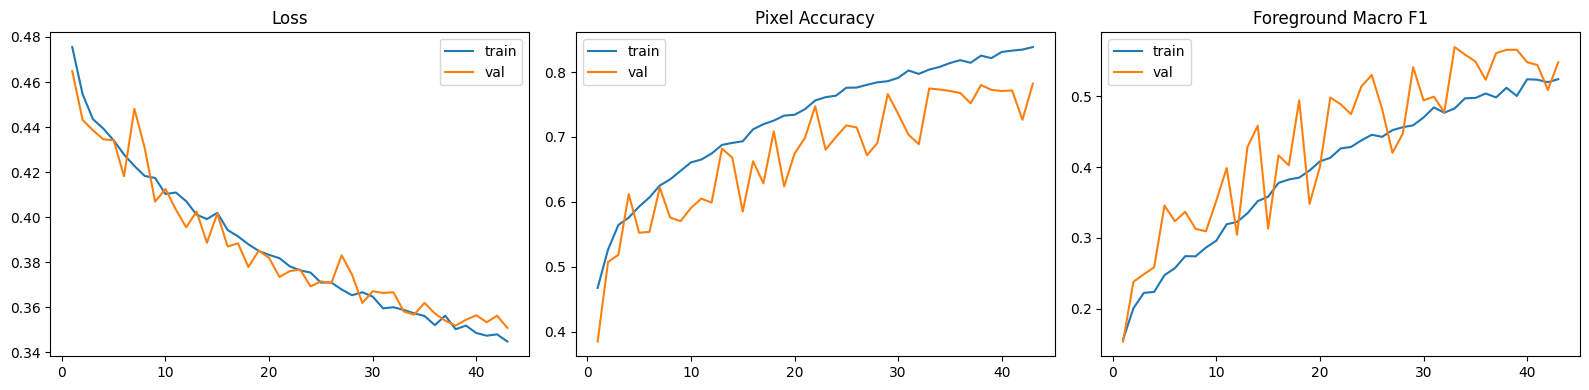

In [ ]:
# =============================================================================
# CELL 9 — TRAINING LOOP
# =============================================================================

resume_path = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pt")


def batch_macro_f1(logits, targets, class_ids=(1, 2, 3), eps=1e-8):
    preds     = torch.argmax(logits, dim=1)
    f1_scores = []

    for cls in class_ids:
        pred_cls = preds   == cls
        true_cls = targets == cls

        tp = (pred_cls &  true_cls).sum().float()
        fp = (pred_cls & ~true_cls).sum().float()
        fn = (~pred_cls &  true_cls).sum().float()

        precision = tp / (tp + fp + eps)
        recall    = tp / (tp + fn + eps)
        f1        = 2 * precision * recall / (precision + recall + eps)
        f1_scores.append(f1)

    return torch.stack(f1_scores).mean().item() if f1_scores else 0.0


def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss, total_acc, total_fg_f1 = 0.0, 0.0, 0.0
    n_batches = 0

    for images, masks in loader:
        images = images.to(device)
        masks  = masks.to(device)

        with torch.set_grad_enabled(train_mode):
            logits = model(images)
            loss   = criterion(logits, masks)

        if train_mode:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss  += loss.item()
        total_acc   += pixel_accuracy(logits.detach(), masks)
        total_fg_f1 += batch_macro_f1(logits.detach(), masks, class_ids=(1, 2, 3))
        n_batches   += 1

    if n_batches == 0:
        return 0.0, 0.0, 0.0

    return total_loss / n_batches, total_acc / n_batches, total_fg_f1 / n_batches


# =============================================================================
# Training state — initialise fresh, then OVERWRITE if checkpoint exists
# =============================================================================
history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  [],
    "train_fg_f1": [], "val_fg_f1": [],
}

best_val_fg_f1             = -1.0
best_state                 = None
epochs_without_improvement = 0
start_epoch                = 1    

# --- Resume logic ---
if os.path.exists(resume_path):
    print(f"Found checkpoint — resuming from {resume_path}")
    ckpt = torch.load(resume_path, map_location=device)

    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])

    history                    = ckpt["history"]
    best_val_fg_f1             = ckpt["best_val_fg_f1"]
    epochs_without_improvement = ckpt["epochs_without_improvement"]
    start_epoch                = ckpt["epoch"] + 1

    print(f"Resumed from epoch {ckpt['epoch']} — best val_fg_f1={best_val_fg_f1:.4f}")
else:
    print("No checkpoint found — starting from scratch.")


# =============================================================================
# Main training loop
# =============================================================================
for epoch in range(start_epoch, MAX_EPOCHS + 1):

    train_loss, train_acc, train_fg_f1 = run_epoch(
        model, train_loader, criterion, optimizer=optimizer
    )
    val_loss, val_acc, val_fg_f1 = run_epoch(
        model, val_loader, criterion, optimizer=None
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_fg_f1"].append(train_fg_f1)
    history["val_fg_f1"].append(val_fg_f1)

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f} | "
        f"train_acc={train_acc:.4f}  val_acc={val_acc:.4f} | "
        f"train_fg_f1={train_fg_f1:.4f}  val_fg_f1={val_fg_f1:.4f}"
    )

    # --- Check for improvement ---
    if val_fg_f1 > best_val_fg_f1 + 1e-4:
        best_val_fg_f1             = val_fg_f1
        best_state                 = {k: v.detach().cpu().clone()
                                      for k, v in model.state_dict().items()}
        epochs_without_improvement = 0

        # Save best model separately — never overwritten unless improved
        torch.save(
            {"model_state_dict": best_state,
             "num_classes":      NUM_CLASSES,
             "img_size":         IMG_SIZE,
             "class_names":      CLASS_NAMES,
             "class_to_id":      CLASS_TO_ID,
             "val_fg_f1":        best_val_fg_f1},
            os.path.join(CHECKPOINT_DIR, "best_model.pt")
        )
        print(f"✅ New best val_fg_f1={best_val_fg_f1:.4f} — saved best_model.pt")
    else:
        epochs_without_improvement += 1

    # --- Save latest checkpoint every epoch so resume is always possible ---
    torch.save(
        {
            "epoch":                      epoch,
            "model_state_dict":           model.state_dict(),
            "optimizer_state_dict":       optimizer.state_dict(),
            "scheduler_state_dict":       scheduler.state_dict(),
            "history":                    history,
            "best_val_fg_f1":             best_val_fg_f1,
            "epochs_without_improvement": epochs_without_improvement,
        },
        resume_path    # overwrites latest_checkpoint.pt every epoch
    )

    # --- Early stopping ---
    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch} "
              f"(no improvement for {PATIENCE} epochs)")
        break


# Restore best weights
if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)
    print(f"\nRestored best model — val_fg_f1={best_val_fg_f1:.4f}")


# =============================================================================
# Plot training curves
# =============================================================================
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].plot(epochs_range, history["train_loss"], label="train")
ax[0].plot(epochs_range, history["val_loss"],   label="val")
ax[0].set_title("Loss")
ax[0].legend()

ax[1].plot(epochs_range, history["train_acc"], label="train")
ax[1].plot(epochs_range, history["val_acc"],   label="val")
ax[1].set_title("Pixel Accuracy")
ax[1].legend()

ax[2].plot(epochs_range, history["train_fg_f1"], label="train")
ax[2].plot(epochs_range, history["val_fg_f1"],   label="val")
ax[2].set_title("Foreground Macro F1")
ax[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# CELL 10 — SAVE BEST MODEL CHECKPOINT TO DISK
# =============================================================================
# Saves the trained model weights along with the metadata needed to reconstruct
# and use it in a future session (without re-running any data or training cells).
#
# Saved fields:
#   model_state_dict : all trained weight tensors
#   num_classes      : number of output classes (needed to build the UNet)
#   img_size         : model input size (needed for preprocessing at inference)
#   class_names      : ["Car", "Cat", "Bird"]
#   class_to_id      : {"Car": 1, "Cat": 2, "Bird": 3}
# =============================================================================

from pathlib import Path
from google.colab import drive

# Mount Drive if not already mounted
if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")

# Save checkpoint to Drive so it persists across sessions
checkpoint_dir  = Path("/content/drive/MyDrive/checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = checkpoint_dir / "unet_car_cat_bird_best_final2.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "num_classes":      NUM_CLASSES,
        "img_size":         IMG_SIZE,
        "class_names":      CLASS_NAMES,
        "class_to_id":      CLASS_TO_ID,
    },
    checkpoint_path,
)
print(f"Saved checkpoint to: {checkpoint_path}")


# ---------------------------------------------------------------------------
# Utility function to reload the model from a checkpoint file
# ---------------------------------------------------------------------------
def load_trained_unet(path, device):
    """
    Reconstructs and loads a UNetResNet34 from a saved checkpoint.

    Args:
        path   : path to the .pt checkpoint file
        device : torch.device to load the model onto

    Returns:
        loaded_model : UNetResNet34 in eval() mode with trained weights
        ckpt         : the full checkpoint dict (includes metadata)
    """
    ckpt         = torch.load(path, map_location=device)
    loaded_model = UNetMobileNetV2(n_classes=ckpt["num_classes"]).to(device)
    loaded_model.load_state_dict(ckpt["model_state_dict"])

Saved checkpoint to: /content/drive/MyDrive/checkpoints/unet_car_cat_bird_best_final2.pt


## After Closing — Standalone Inference Section

The cells below can be run **independently in a new session** (without re-running data download or training).

**Minimum required cells to run first:**
1. Import / setup cell (Cell 2, 4, 5 and 7) — defines `device`, `UNet`, and helper functions
2. The checkpoint loader cell directly below — restores all weights and metadata

After that, you can run evaluation or external-image inference without touching FiftyOne or the training pipeline.


In [17]:
# =============================================================================
# CELL 11 — LOAD MODEL FROM CHECKPOINT (PREVIOUS SESSION)
# =============================================================================
# Restores the trained model and all metadata from the saved checkpoint file.
# Run this cell instead of the full training pipeline when the model is already
# trained and saved to disk.
#
# Prerequisites: the UNet class must be defined (run Cell 8).
# =============================================================================

import torch
from pathlib import Path

device          = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_path = Path("checkpoints/unet_car_cat_bird_best_final2.pt")

if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Checkpoint not found at '{checkpoint_path}'. "
        "Run the training cells (Cells 8–11) first to train and save the model."
    )

# Load the full checkpoint dictionary from disk
ckpt = torch.load(checkpoint_path, map_location=device)

# --- Restore hyperparameters from checkpoint metadata ---
# These values are needed by evaluation and inference cells
NUM_CLASSES = ckpt["num_classes"]
IMG_SIZE    = ckpt["img_size"]
CLASS_NAMES = ckpt["class_names"]
CLASS_TO_ID = ckpt["class_to_id"]

# --- Reconstruct the UNet and load trained weights ---
model = UNet(in_channels=3, n_classes=NUM_CLASSES).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()  # switch to inference mode (disables dropout / batchnorm training behaviour)

print(f"Loaded checkpoint from : {checkpoint_path}")
print(f"Device                 : {device}")
print(f"Classes                : {CLASS_NAMES}")
print(f"Image size             : {IMG_SIZE}×{IMG_SIZE},  Num classes: {NUM_CLASSES}")


Loaded checkpoint from : /content/drive/MyDrive/checkpoints/unet_car_cat_bird_best_final2.pt
Device                 : cuda
Classes                : ['Car', 'Cat', 'Bird']
Image size             : 256×256,  Num classes: 4


Mean IoU per class:
  background: 0.7208
  Car: 0.2054
  Cat: 0.4524
  Bird: 0.2949
Overall mIoU: 0.4184


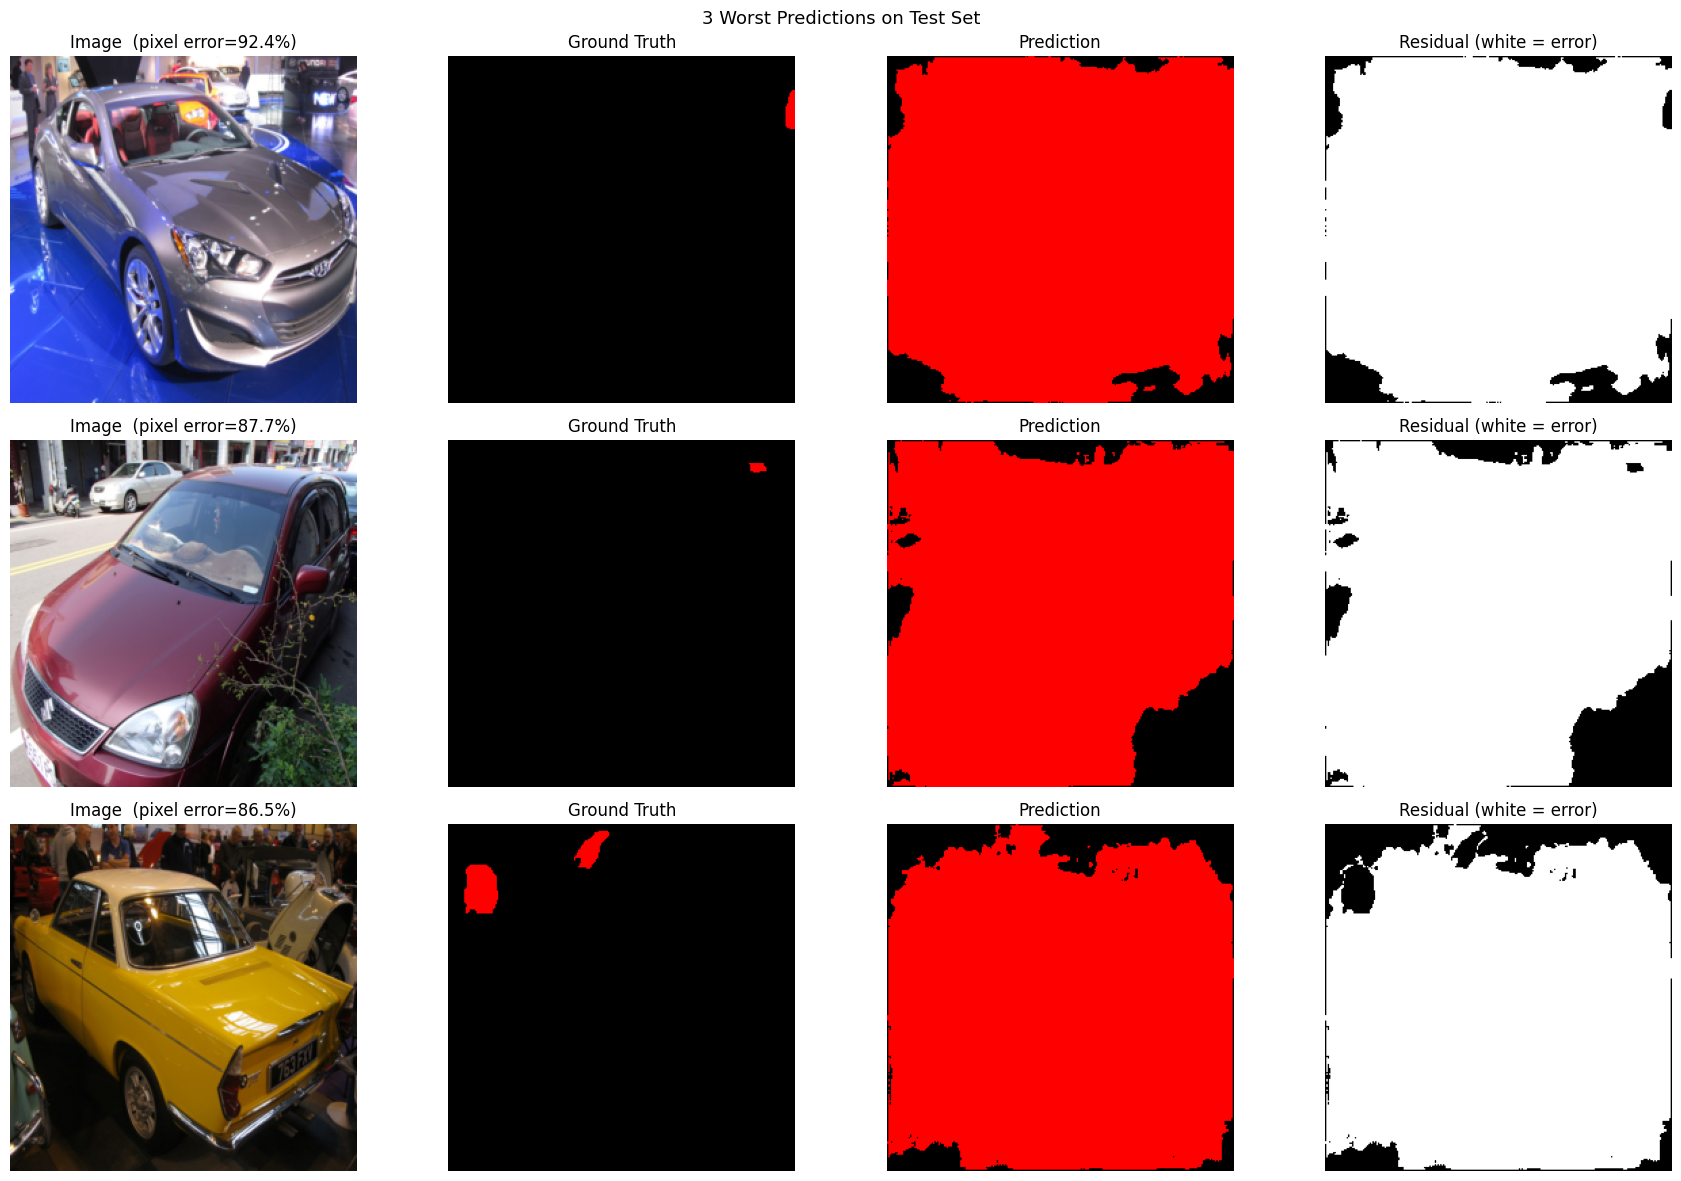

In [ ]:
# =============================================================================
# CELL 12 — EVALUATION ON TEST SET: mIoU AND RESIDUAL ANALYSIS
# =============================================================================
# Runs the model over the full test set and computes:
#   - Per-class mean IoU (Intersection over Union)
#   - Overall mIoU (mean across all classes including background)
#
# Additionally, identifies the 3 test images with the highest pixel error rate
# and displays them side-by-side with their ground truth, prediction, and
# residual map (white = misclassified pixel).
# =============================================================================

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


def per_class_iou(pred, target, num_classes):
    """
    Computes per-class IoU for a single image pair.

    IoU = |pred ∩ target| / |pred ∪ target|

    Returns NaN for a class that does not appear in either pred or target
    (no ground truth and no prediction → undefined, not a failure).
    """
    ious = []
    for cls in range(num_classes):
        pred_c   = pred   == cls
        target_c = target == cls
        inter = np.logical_and(pred_c, target_c).sum()
        union = np.logical_or(pred_c,  target_c).sum()
        iou   = inter / union if union > 0 else np.nan
        ious.append(iou)
    return ious


if len(test_loader) == 0:
    raise ValueError("Test split is empty. Run Cell 4 to build test_loader.")

model.eval()
all_ious     = []
residual_pool = []  # list of (error_rate, image, true_mask, pred_mask, residual)

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks  = masks.to(device)
        logits = model(images)
        preds  = torch.argmax(logits, dim=1)  # (B, H, W) predicted class per pixel

        for b in range(images.shape[0]):
            pred_np = preds[b].cpu().numpy()
            true_np = masks[b].cpu().numpy()
            img_np  = images[b].cpu().permute(1, 2, 0).numpy()

            # Per-class IoU for this image
            ious = per_class_iou(pred_np, true_np, NUM_CLASSES)
            all_ious.append(ious)

            # Residual map: 1 where model is wrong, 0 where correct
            residual   = (pred_np != true_np).astype(np.uint8)
            error_rate = residual.mean()  # fraction of misclassified pixels
            residual_pool.append((error_rate, img_np, true_np, pred_np, residual))

all_ious = np.array(all_ious, dtype=np.float32)
if all_ious.size == 0:
    raise ValueError("No predictions collected. Check test_loader.")

# --- Print per-class and overall mIoU ---
mean_iou_per_class = np.nanmean(all_ious, axis=0)
name_by_id = ["background", "Car", "Cat", "Bird"]

print("Mean IoU per class:")
for i, score in enumerate(mean_iou_per_class):
    print(f"  {name_by_id[i]}: {score:.4f}")
print(f"Overall mIoU: {np.nanmean(mean_iou_per_class):.4f}")

# --- Visualise the 3 worst predictions (highest pixel error rate) ---
residual_pool.sort(key=lambda x: x[0], reverse=True)
worst_k = min(3, len(residual_pool))

cmap = ListedColormap(["black", "red", "deepskyblue", "lime"])
fig, axes = plt.subplots(worst_k, 4, figsize=(18, 4 * worst_k))
if worst_k == 1:
    axes = np.expand_dims(axes, axis=0)

for r in range(worst_k):
    err, img, true_m, pred_m, resid = residual_pool[r]

    axes[r, 0].imshow(img)
    axes[r, 0].set_title(f"Image  (pixel error={err:.1%})")
    axes[r, 0].axis("off")

    axes[r, 1].imshow(true_m, cmap=cmap, vmin=0, vmax=3)
    axes[r, 1].set_title("Ground Truth")
    axes[r, 1].axis("off")

    axes[r, 2].imshow(pred_m, cmap=cmap, vmin=0, vmax=3)
    axes[r, 2].set_title("Prediction")
    axes[r, 2].axis("off")

    # Residual map: white pixels = model made a mistake there
    axes[r, 3].imshow(resid, cmap="gray")
    axes[r, 3].set_title("Residual (white = error)")
    axes[r, 3].axis("off")

plt.suptitle("3 Worst Predictions on Test Set", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# =============================================================================
# CELL 13 — PER-CLASS METRICS ON THE FULL TEST SET
# =============================================================================
# Computes pixel-level, one-vs-rest classification metrics for each foreground
# class (Car, Cat, Bird) over all test images:
#
#   Accuracy  = (TP + TN) / (TP + TN + FP + FN)
#   Precision = TP / (TP + FP)   — how often a predicted pixel is correct
#   Recall    = TP / (TP + FN)   — how many ground-truth pixels are found
#   F1        = 2 × P × R / (P + R)
#
# All comparisons are pixel-level (each pixel is treated as a binary
# classification: "is this pixel class X?" vs "is it something else?").
# Macro-average across classes is printed at the bottom.
# =============================================================================

selected_classes   = ["Car", "Cat", "Bird"]
max_unseen_images  = len(test_dataset)  # evaluate on every test image

if len(test_loader) == 0:
    raise ValueError("Test split is empty. Run the data-preparation cells first.")

missing_classes = [c for c in selected_classes if c not in CLASS_TO_ID]
if missing_classes:
    raise ValueError(f"Classes not found in CLASS_TO_ID: {missing_classes}")


def safe_div(num, den):
    """Division that returns 0.0 instead of raising ZeroDivisionError."""
    return float(num) / float(den) if den > 0 else 0.0


# Accumulate TP / FP / FN / TN pixel counts across all test images per class
stats = {cls: {"tp": 0, "fp": 0, "fn": 0, "tn": 0} for cls in selected_classes}

processed_images = 0
model.eval()

with torch.no_grad():
    for images, masks in test_loader:
        if processed_images >= max_unseen_images:
            break

        images = images.to(device)
        masks  = masks.to(device)
        logits = model(images)
        preds  = torch.argmax(logits, dim=1)

        # Only process up to the requested number of images
        use_n = min(images.shape[0], max_unseen_images - processed_images)

        for b in range(use_n):
            y_true = masks[b].cpu().numpy()
            y_pred = preds[b].cpu().numpy()

            for cls in selected_classes:
                cls_id = CLASS_TO_ID[cls]

                # Binary masks: 1 = this pixel belongs to `cls`, 0 = it does not
                true_bin = y_true == cls_id
                pred_bin = y_pred == cls_id

                tp = np.logical_and( true_bin,  pred_bin).sum()
                fp = np.logical_and(~true_bin,  pred_bin).sum()
                fn = np.logical_and( true_bin, ~pred_bin).sum()
                tn = np.logical_and(~true_bin, ~pred_bin).sum()

                stats[cls]["tp"] += int(tp)
                stats[cls]["fp"] += int(fp)
                stats[cls]["fn"] += int(fn)
                stats[cls]["tn"] += int(tn)

        processed_images += use_n

if processed_images == 0:
    raise ValueError("No test images were processed.")

# --- Print results table ---
print(f"Evaluated on {processed_images} test images (one-vs-rest, pixel level)\n")
print(f"{'Class':<10} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 54)

macro_acc, macro_prec, macro_rec, macro_f1 = [], [], [], []

for cls in selected_classes:
    tp, fp = stats[cls]["tp"], stats[cls]["fp"]
    fn, tn = stats[cls]["fn"], stats[cls]["tn"]

    accuracy  = safe_div(tp + tn, tp + tn + fp + fn)
    precision = safe_div(tp, tp + fp)
    recall    = safe_div(tp, tp + fn)   # also called "recovery rate"
    f1        = safe_div(2 * precision * recall, precision + recall)

    macro_acc.append(accuracy)
    macro_prec.append(precision)
    macro_rec.append(recall)
    macro_f1.append(f1)

    print(f"{cls:<10} {accuracy:>10.4f} {precision:>10.4f} {recall:>10.4f} {f1:>10.4f}")

print("-" * 54)
print(
    f"{'Macro avg':<10} "
    f"{np.mean(macro_acc):>10.4f} "
    f"{np.mean(macro_prec):>10.4f} "
    f"{np.mean(macro_rec):>10.4f} "
    f"{np.mean(macro_f1):>10.4f}"
)


Evaluated on 600 test images (one-vs-rest, pixel level)

Class        Accuracy  Precision     Recall         F1
------------------------------------------------------
Car            0.8692     0.3371     0.9649     0.4996
Cat            0.9476     0.7883     0.9042     0.8423
Bird           0.9652     0.5899     0.8263     0.6884
------------------------------------------------------
Macro avg      0.9273     0.5718     0.8985     0.6768


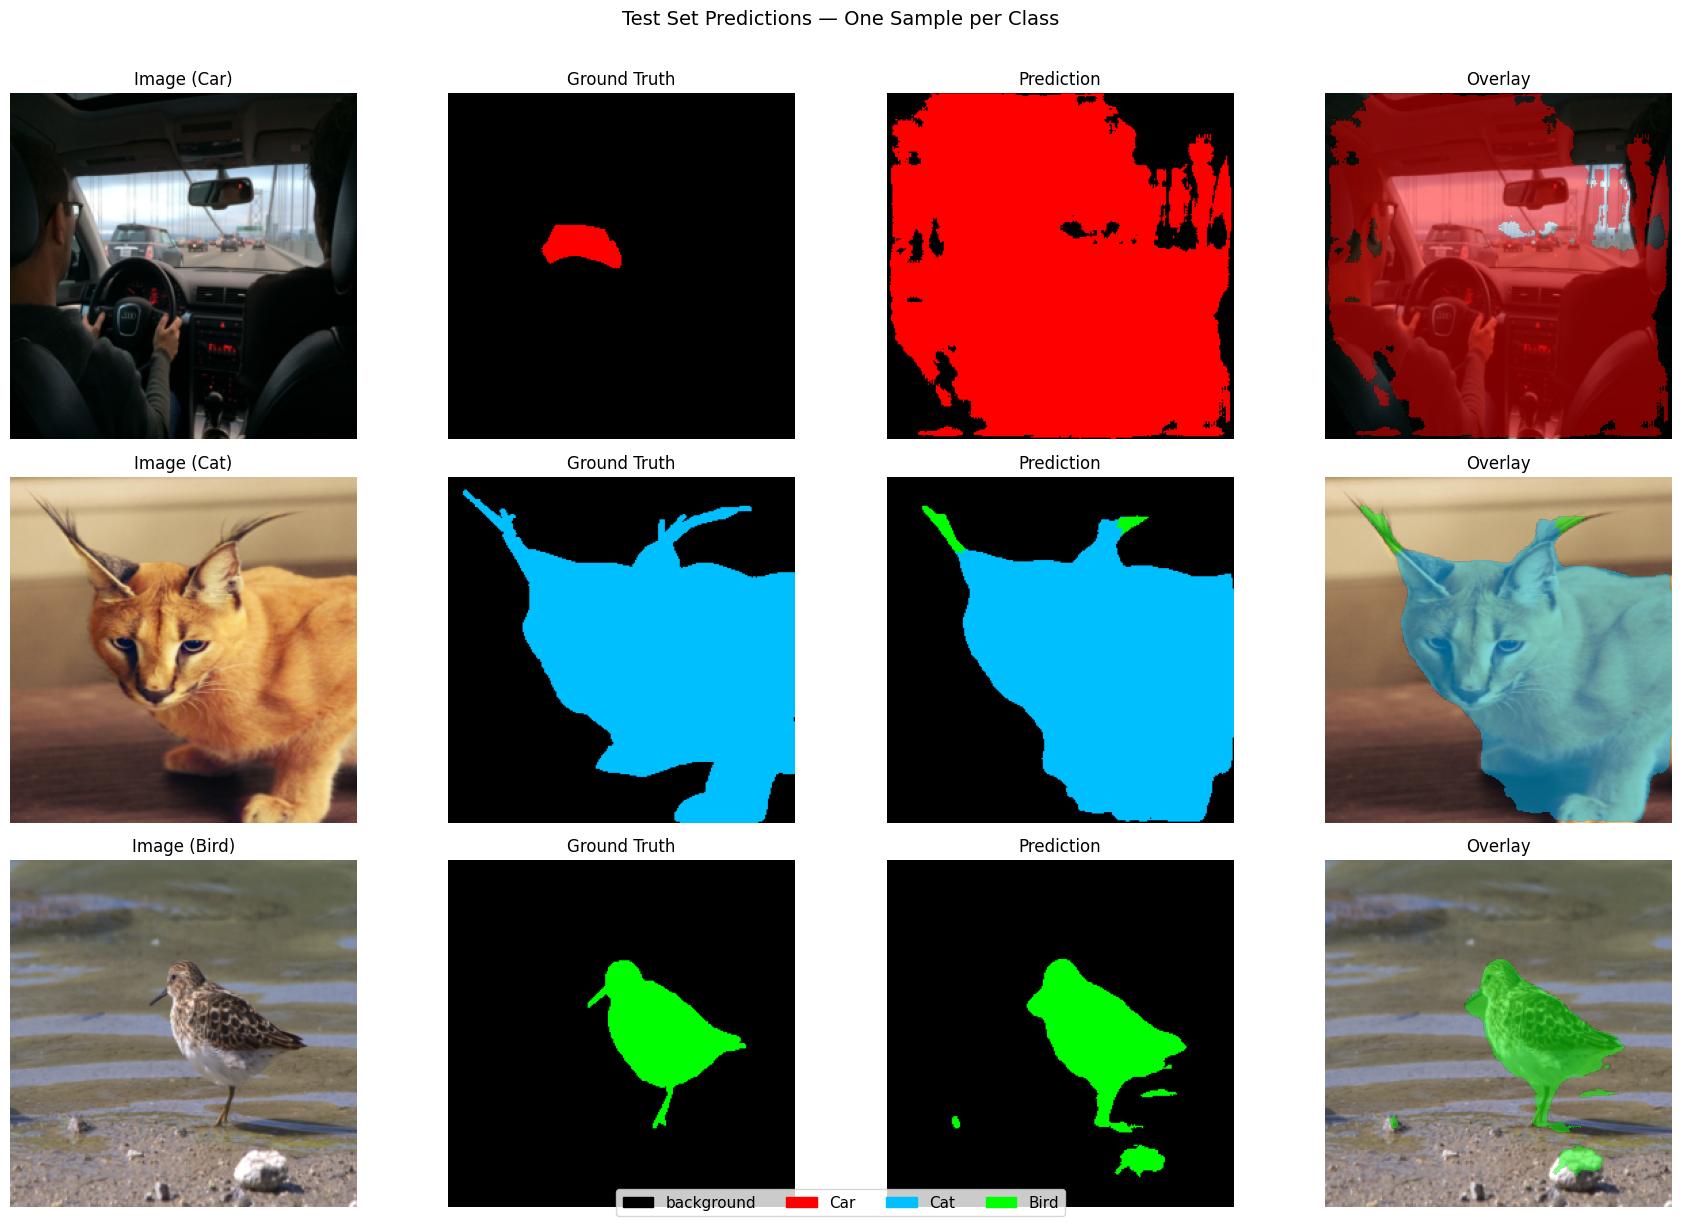

In [ ]:
# =============================================================================
# CELL 14 — VISUALISE PREDICTIONS ON TEST SET (ONE SAMPLE PER CLASS)
# =============================================================================
# Scans the test set and picks one representative image for each foreground
# class (Car, Cat, Bird). "Representative" = the image where that class covers
# the most pixels in the ground-truth mask (dominant class).
#
# For each sample, shows 4 panels:
#   1. Original image
#   2. Ground-truth segmentation mask
#   3. Model prediction mask
#   4. Prediction overlaid on the original image (semi-transparent)
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import numpy as np
import torch

# Colour map: 0=black(bg), 1=red(Car), 2=deepskyblue(Cat), 3=lime(Bird)
cmap        = ListedColormap(["black", "red", "deepskyblue", "lime"])
name_by_id  = {0: "background", 1: "Car", 2: "Cat", 3: "Bird"}
color_by_id = {0: "black",      1: "red", 2: "deepskyblue", 3: "lime"}

# Slot to hold one example per foreground class
collected_per_class = {1: None, 2: None, 3: None}  # Car=1, Cat=2, Bird=3

model.eval()
with torch.no_grad():
    for images, masks in test_loader:
        # Stop early once we have collected one image per class
        if all(v is not None for v in collected_per_class.values()):
            break

        images = images.to(device)
        masks  = masks.to(device)
        logits = model(images)
        preds  = torch.argmax(logits, dim=1)

        for b in range(images.shape[0]):
            gt_np = masks[b].cpu().numpy()

            # Identify the foreground class with the highest pixel count
            best_cls_id, best_count = None, 0
            for cls_id in [1, 2, 3]:
                count = (gt_np == cls_id).sum()
                if count > best_count:
                    best_count  = count
                    best_cls_id = cls_id

            # Store the image/gt/pred tuple for this class if not yet collected
            if best_cls_id is not None and collected_per_class[best_cls_id] is None:
                collected_per_class[best_cls_id] = (
                    images[b].cpu().permute(1, 2, 0).numpy(),  # (H,W,3)
                    gt_np,
                    preds[b].cpu().numpy(),
                )

# Build ordered display list: Car → Cat → Bird (skip any that weren't found)
collected    = [collected_per_class[c] for c in [1, 2, 3] if collected_per_class[c] is not None]
class_labels = [name_by_id[c]          for c in [1, 2, 3] if collected_per_class[c] is not None]

if not collected:
    raise ValueError("No foreground samples found in the test set.")

fig, axes = plt.subplots(len(collected), 4, figsize=(18, 4 * len(collected)))
if len(collected) == 1:
    axes = np.expand_dims(axes, axis=0)

legend_patches = [mpatches.Patch(color=color_by_id[i], label=name_by_id[i]) for i in range(4)]

for r, ((img, gt, pred), cls_label) in enumerate(zip(collected, class_labels)):
    axes[r, 0].imshow(img)
    axes[r, 0].set_title(f"Image ({cls_label})")
    axes[r, 0].axis("off")

    axes[r, 1].imshow(gt, cmap=cmap, vmin=0, vmax=3)
    axes[r, 1].set_title("Ground Truth")
    axes[r, 1].axis("off")

    axes[r, 2].imshow(pred, cmap=cmap, vmin=0, vmax=3)
    axes[r, 2].set_title("Prediction")
    axes[r, 2].axis("off")

    # Overlay: mask background pixels are transparent → shows image underneath
    axes[r, 3].imshow(img)
    axes[r, 3].imshow(
        np.ma.masked_where(pred == 0, pred), cmap=cmap, alpha=0.5, vmin=0, vmax=3
    )
    axes[r, 3].set_title("Overlay")
    axes[r, 3].axis("off")

fig.legend(handles=legend_patches, loc="lower center", ncol=4, fontsize=11, frameon=True)
plt.suptitle("Test Set Predictions — One Sample per Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


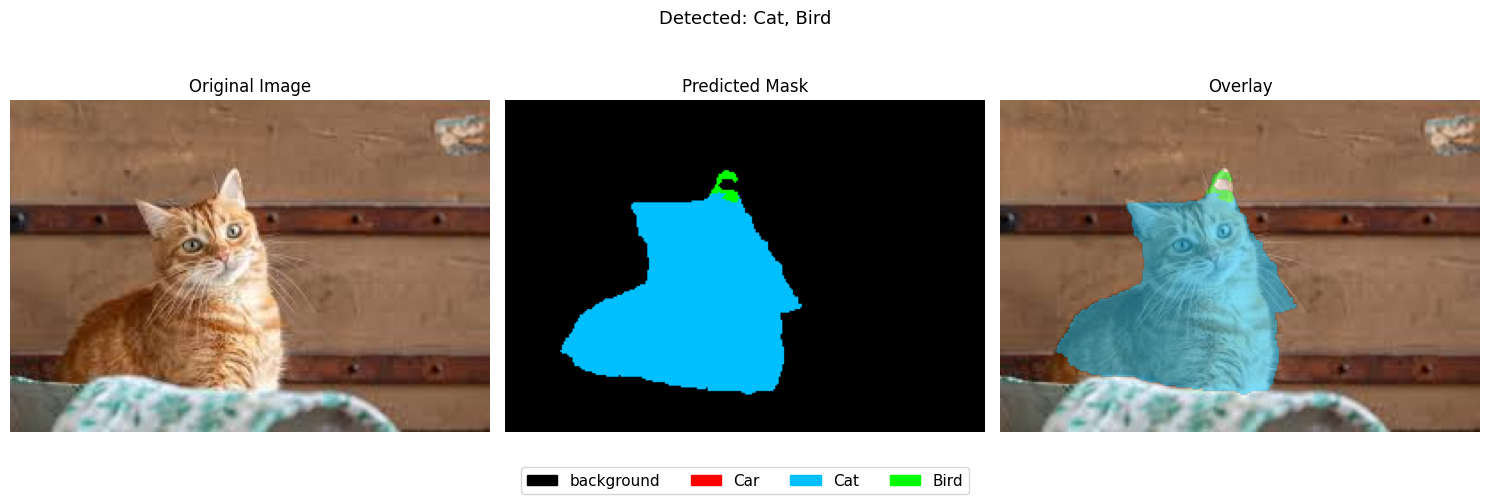

In [ ]:
# =============================================================================
# CELL 15 — INFERENCE ON AN EXTERNAL IMAGE
# =============================================================================
# Runs the trained model on any user-provided photo and visualises the result.
#
# Preprocessing:
#   1. Load image as RGB PIL object
#   2. Resize to 256×256 (matching training)
#   3. Normalise to [0, 1] float32 (matching FiftyOneSegDataset)
#   4. Convert to tensor [1, 3, 256, 256] with a batch dimension
#
# Post-processing:
#   - Argmax over the 4 class logits → predicted class per pixel
#   - Resize prediction back to the ORIGINAL image dimensions using
#     nearest-neighbour interpolation (preserves integer class IDs)
#
# This resize step is critical: without it the mask and the original image
# have different spatial sizes and the overlay would appear misaligned.
# =============================================================================

import torch
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import numpy as np


def predict_external_image(model, image_path, device, img_size=256):
    """
    Segments an external image and displays three panels:
      - Original image
      - Predicted segmentation mask
      - Mask overlaid on the original image

    Args:
        model      : trained UNet (must be in eval mode)
        image_path : path to any RGB image file
        device     : torch.device
        img_size   : input resolution expected by the model (default: 256)
    """
    # ------------------------------------------------------------------
    # 1. LOAD AND PREPROCESS THE IMAGE
    # ------------------------------------------------------------------
    raw_img = Image.open(image_path).convert("RGB")
    original_width, original_height = raw_img.size

    # Resize to the model's expected input size
    img_resized = raw_img.resize((img_size, img_size), Image.BILINEAR)

    # Normalise to [0, 1] — must match the normalisation used during training
    img_np     = np.array(img_resized).astype(np.float32) / 255.0

    # Convert to tensor and add a batch dimension: (H,W,C) → (1,C,H,W)
    img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).to(device)

    # ------------------------------------------------------------------
    # 2. RUN INFERENCE
    # ------------------------------------------------------------------
    model.eval()
    with torch.no_grad():
        logits    = model(img_tensor)                         # (1, 4, 256, 256) raw scores
        preds     = torch.argmax(logits, dim=1)               # (1, 256, 256) class IDs
        preds_256 = preds.squeeze(0).cpu().numpy()            # (256, 256)

    # Upsample the prediction mask back to the original image resolution.
    # NEAREST interpolation preserves integer class IDs (no blending between classes).
    preds_full = np.array(
        Image.fromarray(preds_256.astype(np.uint8)).resize(
            (original_width, original_height), Image.NEAREST
        )
    )

    # ------------------------------------------------------------------
    # 3. VISUALISE RESULTS
    # ------------------------------------------------------------------
    cmap        = ListedColormap(["black", "red", "deepskyblue", "lime"])
    name_by_id  = {0: "background", 1: "Car", 2: "Cat", 3: "Bird"}
    color_by_id = {0: "black",      1: "red", 2: "deepskyblue", 3: "lime"}

    # List which foreground classes were actually detected
    detected     = [name_by_id[i] for i in range(1, 4) if np.any(preds_full == i)]
    detected_str = ", ".join(detected) if detected else "none"

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(raw_img)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(preds_full, cmap=cmap, vmin=0, vmax=3)
    axes[1].set_title("Predicted Mask")
    axes[1].axis("off")

    # Overlay: mask background (class 0) is masked out so the image shows through
    axes[2].imshow(raw_img)
    masked_preds = np.ma.masked_where(preds_full == 0, preds_full)
    axes[2].imshow(masked_preds, cmap=cmap, alpha=0.5, vmin=0, vmax=3)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    legend_patches = [mpatches.Patch(color=color_by_id[i], label=name_by_id[i]) for i in range(4)]
    fig.legend(handles=legend_patches, loc="lower center", ncol=4, fontsize=11, frameon=True)
    plt.suptitle(f"Detected: {detected_str}", fontsize=13)
    plt.tight_layout()
    plt.show()


# --- HOW TO USE ---
# Change `your_photo_path` to any image file on your machine.
# The model will segment Cars (red), Cats (blue), and Birds (green).
your_photo_path = r"C:\Users\Namai\Desktop\img1.jpg"
predict_external_image(model, your_photo_path, device)


In [ ]:
# =============================================================================
# CELL — PIXEL-LEVEL PREDICTION AT A GIVEN COORDINATE (123, 123)
# =============================================================================
# Runs the model on an image and reports what class the model predicts
# at pixel (x=123, y=123), along with the softmax confidence scores.
# =============================================================================

import torch
import numpy as np
from PIL import Image

# --- Configuration ---
your_photo_path = r"C:\Users\Namai\Desktop\img1.jpg"  # path to any RGB image file
pixel_x, pixel_y = 123, 123   # (column, row) — i.e. x=123, y=123
IMG_SIZE = 256

name_by_id  = {0: "background", 1: "Car", 2: "Cat", 3: "Bird"}

# --- 1. Load and preprocess ---
raw_img = Image.open(your_photo_path).convert("RGB")
original_width, original_height = raw_img.size

img_resized = raw_img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
img_np      = np.array(img_resized).astype(np.float32) / 255.0
img_tensor  = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).to(device)

# --- 2. Inference ---
model.eval()
with torch.no_grad():
    logits = model(img_tensor)                        # (1, 4, 256, 256)
    probs  = torch.softmax(logits, dim=1)             # convert to probabilities
    preds  = torch.argmax(logits, dim=1)              # (1, 256, 256)

# Resize prediction mask back to original image size
preds_np = preds.squeeze(0).cpu().numpy().astype(np.uint8)  # (256, 256)
preds_full = np.array(
    Image.fromarray(preds_np).resize((original_width, original_height), Image.NEAREST)
)

# --- 3. Query pixel (123, 123) ---
pred_class_id   = preds_full[pixel_y, pixel_x]          # row=y, col=x
pred_class_name = name_by_id[pred_class_id]

# Also get per-class softmax scores at the model-resolution pixel
# Map (123, 123) from original coords → 256x256 model coords
model_x = int(round(pixel_x * IMG_SIZE / original_width))
model_y = int(round(pixel_y * IMG_SIZE / original_height))
model_x = min(model_x, IMG_SIZE - 1)
model_y = min(model_y, IMG_SIZE - 1)

pixel_probs = probs[0, :, model_y, model_x].cpu().numpy()  # (4,)

# --- 4. Report ---
print(f"Image size (original): {original_width} x {original_height}")
print(f"\nPixel ({pixel_x}, {pixel_y}) prediction:")
print(f"  → Predicted class : {pred_class_name} (ID={pred_class_id})")
print(f"\n  Softmax confidence scores:")
for cid, cname in name_by_id.items():
    print(f"    {cname:12s}: {pixel_probs[cid]:.4f}  ({pixel_probs[cid]*100:.1f}%)")

Image size (original): 270 x 187

Pixel (123, 123) prediction:
  → Predicted class : Cat (ID=2)

  Softmax confidence scores:
    background  : 0.0003  (0.0%)
    Car         : 0.0005  (0.1%)
    Cat         : 0.7890  (78.9%)
    Bird        : 0.2102  (21.0%)


In [ ]:
# Demonstrate: single-label per pixel — each pixel gets exactly ONE class

print("Single-label classification at pixel level\n")

# Show the raw logits and softmax for pixel (123, 123)
print(f"Raw logits at pixel (123, 123):   {logits[0, :, model_y, model_x].cpu().numpy()}")
print(f"Softmax probs at pixel (123, 123): {pixel_probs.round(4)}")
print(f"Argmax (predicted class):          {pred_class_id} → '{pred_class_name}'")
print(f"\nAll probabilities sum to: {pixel_probs.sum():.4f}")  # always 1.0

Single-label classification at pixel level

Raw logits at pixel (123, 123):   [-4.7417965 -4.2523613  3.109124   1.7862198]
Softmax probs at pixel (123, 123): [3.000e-04 5.000e-04 7.890e-01 2.102e-01]
Argmax (predicted class):          2 → 'Cat'

All probabilities sum to: 1.0000


Image size (original): 270 x 187

Pixel (123, 123) prediction:
  → Predicted class : Cat (ID=2)

  Softmax confidence scores:
    background  : 0.0003  (0.0%)
    Car         : 0.0005  (0.1%)
    Cat         : 0.7890  (78.9%)
    Bird        : 0.2102  (21.0%)


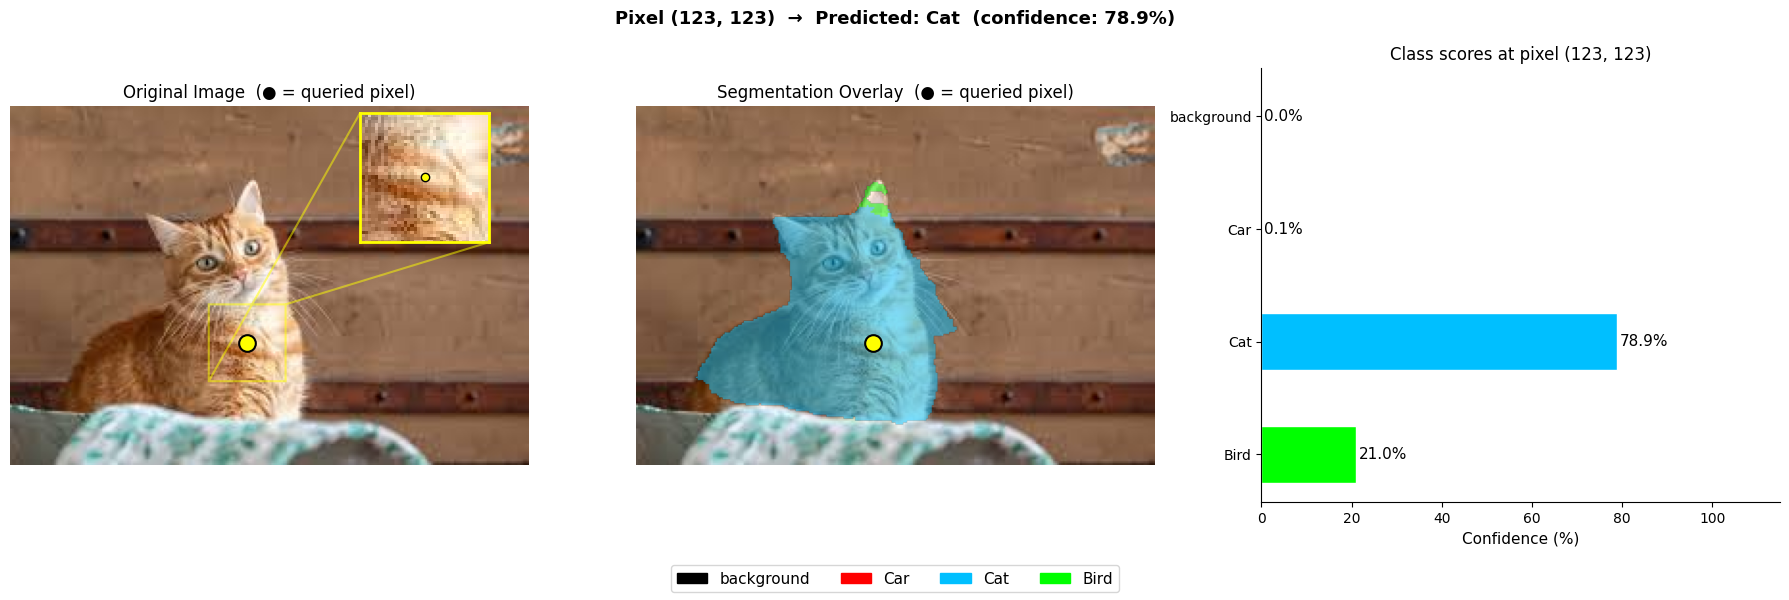

In [ ]:
# =============================================================================
# CELL — PIXEL-LEVEL PREDICTION AT A GIVEN COORDINATE (123, 123)
# =============================================================================

import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# --- Configuration ---
your_photo_path = r"C:\Users\Namai\Desktop\img1.jpg"  # <-- change if needed
pixel_x, pixel_y = 123, 123
IMG_SIZE = 256

name_by_id  = {0: "background", 1: "Car", 2: "Cat", 3: "Bird"}
color_by_id = {0: "black",      1: "red", 2: "deepskyblue", 3: "lime"}

# --- 1. Load and preprocess ---
raw_img = Image.open(your_photo_path).convert("RGB")
original_width, original_height = raw_img.size

img_resized = raw_img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
img_np      = np.array(img_resized).astype(np.float32) / 255.0
img_tensor  = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).to(device)

# --- 2. Inference ---
model.eval()
with torch.no_grad():
    logits = model(img_tensor)
    probs  = torch.softmax(logits, dim=1)
    preds  = torch.argmax(logits, dim=1)

preds_np   = preds.squeeze(0).cpu().numpy().astype(np.uint8)
preds_full = np.array(
    Image.fromarray(preds_np).resize((original_width, original_height), Image.NEAREST)
)

# --- 3. Query pixel (123, 123) ---
pred_class_id   = preds_full[pixel_y, pixel_x]
pred_class_name = name_by_id[pred_class_id]
pred_color      = color_by_id[pred_class_id]

model_x = min(int(round(pixel_x * IMG_SIZE / original_width)),  IMG_SIZE - 1)
model_y = min(int(round(pixel_y * IMG_SIZE / original_height)), IMG_SIZE - 1)
pixel_probs = probs[0, :, model_y, model_x].cpu().numpy()

# --- 4. Print report ---
print(f"Image size (original): {original_width} x {original_height}")
print(f"\nPixel ({pixel_x}, {pixel_y}) prediction:")
print(f"  → Predicted class : {pred_class_name} (ID={pred_class_id})")
print(f"\n  Softmax confidence scores:")
for cid, cname in name_by_id.items():
    print(f"    {cname:12s}: {pixel_probs[cid]:.4f}  ({pixel_probs[cid]*100:.1f}%)")

# --- 5. Visualisation ---
cmap = ListedColormap(["black", "red", "deepskyblue", "lime"])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1 — Original image with highlighted pixel
axes[0].imshow(raw_img)
axes[0].plot(pixel_x, pixel_y, marker="o", markersize=12,
             markerfacecolor="yellow", markeredgecolor="black", markeredgewidth=1.5)
# Zoom-in inset: 40x40 px window around the selected pixel
inset_half = 20
x0_ins = max(pixel_x - inset_half, 0)
x1_ins = min(pixel_x + inset_half, original_width)
y0_ins = max(pixel_y - inset_half, 0)
y1_ins = min(pixel_y + inset_half, original_height)
axins = axes[0].inset_axes([0.62, 0.62, 0.36, 0.36])  # top-right corner
axins.imshow(raw_img)
axins.plot(pixel_x, pixel_y, marker="o", markersize=6,
           markerfacecolor="yellow", markeredgecolor="black", markeredgewidth=1)
axins.set_xlim(x0_ins, x1_ins)
axins.set_ylim(y1_ins, y0_ins)  # inverted y so image is upright
axins.set_xticks([])
axins.set_yticks([])
axins.spines[:].set_color("yellow")
axins.spines[:].set_linewidth(2)
axes[0].indicate_inset_zoom(axins, edgecolor="yellow", linewidth=1.5)
axes[0].set_title("Original Image  (● = queried pixel)", fontsize=12)
axes[0].axis("off")

# Panel 2 — Predicted mask with highlighted pixel
masked_preds = np.ma.masked_where(preds_full == 0, preds_full)
axes[1].imshow(raw_img)
axes[1].imshow(masked_preds, cmap=cmap, alpha=0.5, vmin=0, vmax=3)
axes[1].plot(pixel_x, pixel_y, marker="o", markersize=12,
             markerfacecolor="yellow", markeredgecolor="black", markeredgewidth=1.5)
axes[1].set_title("Segmentation Overlay  (● = queried pixel)", fontsize=12)
axes[1].axis("off")

# Panel 3 — Confidence bar chart for the queried pixel
bar_colors = [color_by_id[i] for i in range(4)]
bars = axes[2].barh(
    [name_by_id[i] for i in range(4)],
    [pixel_probs[i] * 100 for i in range(4)],
    color=bar_colors, edgecolor="white", height=0.5
)
# Annotate each bar with its percentage
for bar, prob in zip(bars, pixel_probs):
    axes[2].text(
        bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
        f"{prob*100:.1f}%", va="center", fontsize=11
    )
axes[2].set_xlim(0, 115)
axes[2].set_xlabel("Confidence (%)", fontsize=11)
axes[2].set_title(f"Class scores at pixel ({pixel_x}, {pixel_y})", fontsize=12)
axes[2].invert_yaxis()  # highest bar at top
axes[2].spines["top"].set_visible(False)
axes[2].spines["right"].set_visible(False)

# Shared legend + title
legend_patches = [mpatches.Patch(color=color_by_id[i], label=name_by_id[i]) for i in range(4)]
fig.legend(handles=legend_patches, loc="lower center", ncol=4, fontsize=11, frameon=True)
plt.suptitle(
    f"Pixel ({pixel_x}, {pixel_y})  →  Predicted: {pred_class_name}  "
    f"(confidence: {pixel_probs[pred_class_id]*100:.1f}%)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

Todo:

pagerinti pauksciu klases f1 iki 0.6;     

padaryti bencjmark su clip tipo segmentavimo modeliu

# Clip model

In [ ]:
# Load the CLIPSeg model and processor for zero-shot segmentation
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
processor  = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
clip_model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")
clip_model.eval().to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/974 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/603M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIPSegForImageSegmentation(
  (clip): CLIPSegModel(
    (text_model): CLIPSegTextTransformer(
      (embeddings): CLIPSegTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPSegEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPSegEncoderLayer(
            (self_attn): CLIPSegAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPSegMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=20

In [ ]:
# =============================================================================
# CLIPSEG BENCHMARK
# =============================================================================

import torch.nn.functional as F
from PIL import Image
import numpy as np
import torch

PROMPTS    = ["car", "cat", "bird"]
PROMPT_IDS = [1, 2, 3]


def safe_div(num, den):
    """Division that returns 0.0 instead of raising ZeroDivisionError."""
    return float(num) / float(den) if den > 0 else 0.0


def predict_clipseg_batch(image_paths, prompts, target_size):
    """
    Runs CLIPSeg on a list of image paths.
    Returns a list of (H, W) numpy arrays with class IDs (0=bg,1=Car,2=Cat,3=Bird).
    """
    results = []
    for path in image_paths:
        raw_img = Image.open(path).convert("RGB")
        inputs  = processor(
            text=prompts,
            images=[raw_img] * len(prompts),
            return_tensors="pt",
            padding=True
        )
        inputs = {k: v.to(clip_model.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = clip_model(**inputs)

        logits = outputs.logits
        logits_resized = F.interpolate(
            logits.unsqueeze(0).float(),
            size=target_size,
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        probs       = torch.softmax(logits_resized, dim=0)
        best_prompt = torch.argmax(probs, dim=0)
        max_prob    = probs.max(dim=0).values
        threshold   = 0.4

        pred_mask = torch.zeros_like(best_prompt)
        for i, class_id in enumerate(PROMPT_IDS):
            pred_mask = torch.where(
                (best_prompt == i) & (max_prob >= threshold),
                torch.tensor(class_id, device=clip_model.device),
                pred_mask
            )
        results.append(pred_mask.cpu().numpy().astype(np.int64))

    return results


# -----------------------------------------------------------------------
# Evaluation loop 
# -----------------------------------------------------------------------
selected_classes  = ["Car", "Cat", "Bird"]
max_unseen_images = len(test_dataset)

if len(test_loader) == 0:
    raise ValueError("Test split is empty. Run the data-preparation cells first.")

missing_classes = [c for c in selected_classes if c not in CLASS_TO_ID]
if missing_classes:
    raise ValueError(f"Classes not found in CLASS_TO_ID: {missing_classes}")

stats = {cls: {"tp": 0, "fp": 0, "fn": 0, "tn": 0} for cls in selected_classes}

processed_images = 0
sample_idx       = 0

print(f"Running CLIPSeg on {len(test_dataset)} test images...")

with torch.no_grad():
    for images, masks in test_loader:
        if processed_images >= max_unseen_images:
            break

        use_n = min(images.shape[0], max_unseen_images - processed_images)

        batch_paths = [
            test_samples[sample_idx + b].filepath for b in range(use_n)
        ]

        # CLIPSeg predictions at IMG_SIZE×IMG_SIZE — same resolution as masks
        clip_preds = predict_clipseg_batch(
            batch_paths, PROMPTS, target_size=(IMG_SIZE, IMG_SIZE)
        )

        for b in range(use_n):
            y_true = masks[b].cpu().numpy()   # ground truth — from test_loader
            y_pred = clip_preds[b]            # CLIPSeg prediction

            for cls in selected_classes:
                cls_id   = CLASS_TO_ID[cls]
                true_bin = y_true == cls_id
                pred_bin = y_pred == cls_id

                stats[cls]["tp"] += int(np.logical_and( true_bin,  pred_bin).sum())
                stats[cls]["fp"] += int(np.logical_and(~true_bin,  pred_bin).sum())
                stats[cls]["fn"] += int(np.logical_and( true_bin, ~pred_bin).sum())
                stats[cls]["tn"] += int(np.logical_and(~true_bin, ~pred_bin).sum())

        processed_images += use_n
        sample_idx       += use_n

        if processed_images % 50 == 0:
            print(f"  {processed_images}/{len(test_dataset)}")

# -----------------------------------------------------------------------
# Print CLIPSeg results 
# -----------------------------------------------------------------------
print(f"\nCLIPSeg evaluated on {processed_images} test images "
      f"(one-vs-rest, pixel level)\n")
print(f"{'Class':<10} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 54)

clip_macro_acc, clip_macro_prec, clip_macro_rec, clip_macro_f1 = [], [], [], []
clip_results = {}

for cls in selected_classes:
    tp, fp = stats[cls]["tp"], stats[cls]["fp"]
    fn, tn = stats[cls]["fn"], stats[cls]["tn"]

    accuracy  = safe_div(tp + tn, tp + tn + fp + fn)
    precision = safe_div(tp, tp + fp)
    recall    = safe_div(tp, tp + fn)
    f1        = safe_div(2 * precision * recall, precision + recall)

    clip_macro_acc.append(accuracy)
    clip_macro_prec.append(precision)
    clip_macro_rec.append(recall)
    clip_macro_f1.append(f1)
    clip_results[cls] = (accuracy, precision, recall, f1)

    print(f"{cls:<10} {accuracy:>10.4f} {precision:>10.4f} {recall:>10.4f} {f1:>10.4f}")

print("-" * 54)
print(
    f"{'Macro avg':<10} "
    f"{np.mean(clip_macro_acc):>10.4f} "
    f"{np.mean(clip_macro_prec):>10.4f} "
    f"{np.mean(clip_macro_rec):>10.4f} "
    f"{np.mean(clip_macro_f1):>10.4f}"
)

# -----------------------------------------------------------------------
# Side-by-side comparison with your UNet 
# -----------------------------------------------------------------------
print(f"\n{'='*62}")
print(f"{'Class':<10} {'CLIPSeg F1':>12} {'UNet F1':>12} {'Winner':>12}")
print(f"{'='*62}")

unet_f1s = {"Car": 0.4996, "Cat": 0.8423, "Bird": 0.6884}

for cls in selected_classes:
    clip_f1 = clip_results[cls][3]
    unet_f1 = unet_f1s[cls]
    winner  = "UNet" if unet_f1 > clip_f1 else "CLIPSeg"
    print(f"{cls:<10} {clip_f1:>12.4f} {unet_f1:>12.4f} {winner:>12}")

print(f"{'='*62}")


Running CLIPSeg on 600 test images...
  200/600
  400/600
  600/600

CLIPSeg evaluated on 600 test images (one-vs-rest, pixel level)

Class        Accuracy  Precision     Recall         F1
------------------------------------------------------
Car            0.7333     0.2024     1.0000     0.3366
Cat            0.8241     0.4682     0.9998     0.6377
Bird           0.7116     0.1389     0.9997     0.2439
------------------------------------------------------
Macro avg      0.7563     0.2698     0.9999     0.4061

Class        CLIPSeg F1      UNet F1       Winner
Car              0.3366       0.4996         UNet
Cat              0.6377       0.8423         UNet
Bird             0.2439       0.6884         UNet
